In [11]:
#GRCAE DATA PROCESSING: REGRIDDING AND CLIP FOR INDIA 

import os
from pathlib import Path
import glob
import warnings

import numpy as np
import xarray as xr
import rioxarray  # enables .rio.*
import rasterio
import geopandas as gpd

warnings.filterwarnings("ignore", category=FutureWarning)

# ---------------------- USER PATHS ----------------------
IN_DIR   = r"C:\Drought\GRACE\GRC-GFO_GRIDDED_AOD1B_JPL_MASCON_RL06.3_RL06.3-20250918_155508"
SHP_DIR  = r"C:\Drought\India Shapefile\indiashapefile"
OUT_DIR  = r"C:\Drought\Regridding and data clipping\GRACE"
OUT_FILE = "GRACE_JPL_mascon_India_0p05deg_2003-2023.nc"
# -------------------------------------------------------

CRS_EPSG = 4326
TARGET_RES_DEG = 0.05
FORCE_BOUNDS = None   # e.g., (68.0, 6.0, 98.0, 38.0) for fixed bbox

# Prefer these names if present (liquid water equiv. thickness)
LWE_PREFERRED = [
    "lwe_thickness", "lwe", "lwe_cm", "cmwe", "lwe_grid",
]

# IO tuning
CHUNKS = {"time": 300, "lat": 800, "lon": 800}
COMPRESSION = dict(zlib=True, complevel=4)

# ---------------------- Helpers ----------------------
def find_shp(shp_dir: str) -> Path:
    cand = list(Path(shp_dir).glob("*.shp"))
    if not cand:
        raise FileNotFoundError(f"No .shp file found in: {shp_dir}")
    return cand[0]

def _detect_spatial_dims(dims):
    lon_dim = None
    lat_dim = None
    for d in dims:
        dl = d.lower()
        if lon_dim is None and ("lon" in dl or dl in ("x", "longitude", "nlon")):
            lon_dim = d
        if lat_dim is None and ("lat" in dl or dl in ("y", "latitude", "nlat")):
            lat_dim = d
    return lon_dim, lat_dim

def promote_coord(ds: xr.Dataset, name: str) -> xr.Dataset:
    if name in ds.variables and name not in ds.coords:
        ds = ds.set_coords(name)
    return ds

def normalize_coords_and_dims(ds: xr.Dataset) -> xr.Dataset:
    # Rename variables to lat/lon if needed
    ren_vars = {}
    if "longitude" in ds.variables: ren_vars["longitude"] = "lon"
    if "latitude"  in ds.variables: ren_vars["latitude"]  = "lat"
    if ren_vars:
        ds = ds.rename(ren_vars)

    # Rename dims to lon/lat if needed
    lon_dim, lat_dim = _detect_spatial_dims(ds.dims)
    ren_dims = {}
    if lon_dim and lon_dim != "lon": ren_dims[lon_dim] = "lon"
    if lat_dim and lat_dim != "lat": ren_dims[lat_dim] = "lat"
    if ren_dims:
        ds = ds.rename(ren_dims)

    # Ensure lon/lat are coordinates
    if "lon" in ds.dims: ds = promote_coord(ds, "lon")
    if "lat" in ds.dims: ds = promote_coord(ds, "lat")
    if "lon" in ds.dims and "lon" not in ds.coords and "lon" in ds.variables:
        ds = ds.assign_coords(lon=ds["lon"])
    if "lat" in ds.dims and "lat" not in ds.coords and "lat" in ds.variables:
        ds = ds.assign_coords(lat=ds["lat"])

    # Convert 0..360 → -180..180 if needed
    if "lon" in ds.coords and float(ds["lon"].max()) > 180.0:
        lon = ((ds["lon"] + 180.0) % 360.0) - 180.0
        ds = ds.assign_coords(lon=lon).sortby("lon")

    # Sort ascending
    if "lat" in ds.coords and ds["lat"].values[0] > ds["lat"].values[-1]:
        ds = ds.sortby("lat")
    if "lon" in ds.coords and ds["lon"].values[0] > ds["lon"].values[-1]:
        ds = ds.sortby("lon")
    return ds

def ensure_spatial_ds(ds: xr.Dataset) -> xr.Dataset:
    ds = normalize_coords_and_dims(ds)
    ds = ds.rio.write_crs(CRS_EPSG, inplace=False)
    ds = ds.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=False)
    return ds

def ensure_spatial_da(da: xr.DataArray) -> xr.DataArray:
    
    # Make sure dims/coords are normalized at the Dataset level then pull back the var
    name = da.name if da.name is not None else "var"
    ds = da.to_dataset(name=name)
    ds = ensure_spatial_ds(ds)
    da = ds[name]
    # ALSO set on the DataArray itself (important for rioxarray)
    da = da.rio.write_crs(CRS_EPSG, inplace=False)
    da = da.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=False)
    return da

def bounds_from_shape(gdf: gpd.GeoDataFrame, pad_deg=0.1):
    minx, miny, maxx, maxy = gdf.to_crs(epsg=CRS_EPSG).total_bounds
    return (minx - pad_deg, miny - pad_deg, maxx + pad_deg, maxy + pad_deg)

def build_template(bounds, res_deg=TARGET_RES_DEG) -> xr.Dataset:
    minx, miny, maxx, maxy = bounds
    lons = np.arange(minx, maxx + 1e-12, res_deg)
    lats = np.arange(miny, maxy + 1e-12, res_deg)
    ds = xr.Dataset(coords={"lon": ("lon", lons), "lat": ("lat", lats)})
    return ensure_spatial_ds(ds)

def clip_to_shape_da(da: xr.DataArray, gdf: gpd.GeoDataFrame) -> xr.DataArray:
    da = ensure_spatial_da(da)
    gdf = gdf.to_crs(epsg=CRS_EPSG)
    return da.rio.clip(gdf.geometry, gdf.crs, drop=True, invert=False)

def regrid_to_template_da(da: xr.DataArray, template: xr.Dataset) -> xr.DataArray:
    da = ensure_spatial_da(da)
    template = ensure_spatial_ds(template)
    # Ensure template has a dummy var so transform exists
    if len(template.data_vars) == 0:
        template = template.assign(_dummy=(("lat","lon"),
                              np.zeros((template.sizes["lat"], template.sizes["lon"]))))
        template = ensure_spatial_ds(template)
    out = da.rio.reproject_match(template, resampling=rasterio.enums.Resampling.bilinear)
    return out

def pick_vars(ds: xr.Dataset):
    # Prefer explicit LWE variable if present
    for v in LWE_PREFERRED:
        if v in ds.data_vars:
            return [v]
    # Otherwise keep the 4 mascon components you showed (and skip *bounds)
    bad = set(["lat_bounds", "lon_bounds", "time_bounds", "bounds"])
    keep = [v for v in ds.data_vars if v not in bad and not v.endswith("_bounds")]
    if not keep:
        raise RuntimeError(f"No usable variables found. Available: {list(ds.data_vars)}")
    return keep

# ---------------------- Pipeline ----------------------
def main():
    # India shape & template
    shp_path = find_shp(SHP_DIR)
    india_gdf = gpd.read_file(shp_path)

    bounds = FORCE_BOUNDS if FORCE_BOUNDS is not None else bounds_from_shape(india_gdf, pad_deg=0.1)
    template = build_template(bounds, res_deg=TARGET_RES_DEG)

    # Collect files
    files = sorted(
        glob.glob(str(Path(IN_DIR) / "*.nc"))
        + glob.glob(str(Path(IN_DIR) / "*.nc4"))
    )
    if not files:
        raise RuntimeError(f"No GRACE files found in {IN_DIR}")

    # Open all months
    ds = xr.open_mfdataset(files, combine="by_coords", parallel=False)
    ds = ensure_spatial_ds(ds)

    # Restrict to 2003–2023
    if "time" in ds.coords:
        ds = ds.sel(time=slice("2003-01-01", "2023-12-31"))

    # Pick variables
    keep_vars = pick_vars(ds)
    ds = ds[keep_vars]

    # Quick bbox subset to speed up clip
    minx, miny, maxx, maxy = template.rio.bounds()
    ds = ds.sel(lon=slice(minx, maxx), lat=slice(miny, maxy))

    # Clip + regrid each variable
    out_vars = []
    for v in ds.data_vars:
        da = ds[v]

        # Apply scale_factor/add_offset if present
        sf = da.attrs.get("scale_factor", 1.0)
        ao = da.attrs.get("add_offset", 0.0)
        if sf != 1.0 or ao != 0.0:
            da = (da * sf) + ao

        da = clip_to_shape_da(da, india_gdf)
        da = regrid_to_template_da(da, template)
        da = da.rename(v)
        da.attrs.update({
            "processing_lineage": "monthly; clipped to India; regridded to 0.05° (bilinear)",
            "source": "GRACE/GFO JPL RL06.3 Gridded Mascon",
        })
        out_vars.append(da)

    # Merge variables
    out = xr.merge([d.to_dataset(name=d.name) for d in out_vars], compat="override")
    out = ensure_spatial_ds(out)

    # If exactly one var and it's not called 'lwe_thickness', rename for consistency
    if len(out.data_vars) == 1:
        only = list(out.data_vars)[0]
        if only != "lwe_thickness":
            out = out.rename({only: "lwe_thickness"})

    # Chunking & compression
    try:
        out = out.chunk(CHUNKS)
    except Exception:
        pass
    encoding = {v: {**COMPRESSION} for v in out.data_vars}

    # Global metadata
    out.attrs.update({
        "title": "GRACE/GFO JPL RL06.3 Gridded Mascon – India 0.05°",
        "summary": "Monthly GRACE/GFO JPL RL06.3 gridded fields regridded to 0.05°, clipped to India. LWE preferred when available.",
        "Conventions": "CF-1.8",
        "crs": f"EPSG:{CRS_EPSG}",
        "history": "Created by grace_jpl_mascon_india_0p05_all_years.py",
        "spatial_resolution": "0.05 degree",
        "temporal_coverage": "2003-01 to 2023-12",
    })

    # Save
    os.makedirs(OUT_DIR, exist_ok=True)
    out_path = str(Path(OUT_DIR) / OUT_FILE)
    try:
        out.to_netcdf(out_path, format="NETCDF4", engine="netcdf4", encoding=encoding)
    except Exception:
        try:
            out.to_netcdf(out_path, engine="h5netcdf", encoding=encoding)
        except Exception:
            out.to_netcdf(out_path, engine="scipy", encoding=encoding)

    print(f"\nSaved → {out_path}")

if __name__ == "__main__":
    main()



Saved → C:\Drought\Regridding and data clipping\GRACE\GRACE_JPL_mascon_India_0p05deg_2003-2023.nc


In [21]:
#TERRA CLIMATE DATAPROCESSING
import os
from pathlib import Path
import glob
import warnings

import numpy as np
import xarray as xr
import rioxarray  # enables .rio.* methods
import rasterio
import geopandas as gpd

warnings.filterwarnings("ignore", category=FutureWarning)

# ---------------------- USER PATHS ----------------------
IN_DIR   = r"C:\Drought\TERRA"
SHP_DIR  = r"C:\Drought\India Shapefile\indiashapefile"
OUT_DIR  = r"C:\Drought\Regridding and data clipping\TerraClimate"
# -------------------------------------------------------

CRS_EPSG = 4326
TARGET_RES_DEG = 0.05
FORCE_BOUNDS = None   # e.g., (68.0, 6.0, 98.0, 38.0) to force exact bbox

VARS = {
    "pet":  dict(pattern="TerraClimate_pet_*.nc",  prefer=["pet"]),
    "soil": dict(pattern="TerraClimate_soil_*.nc", prefer=["soil","soil_moisture","soilc","soilw"]),
    "vpd":  dict(pattern="TerraClimate_vpd_*.nc",  prefer=["vpd"]),
}

# IO tuning
CHUNKS = {"time": 300, "lat": 900, "lon": 900}
COMPRESSION = dict(zlib=True, complevel=4)

# ---------------------- helpers ----------------------
def find_shp(shp_dir: str) -> Path:
    cand = list(Path(shp_dir).glob("*.shp"))
    if not cand:
        raise FileNotFoundError(f"No .shp file found in: {shp_dir}")
    return cand[0]

def _detect_spatial_dims(dims):
    lon_dim = None
    lat_dim = None
    for d in dims:
        dl = d.lower()
        if lon_dim is None and ("lon" in dl or dl in ("x", "longitude", "nlon")):
            lon_dim = d
        if lat_dim is None and ("lat" in dl or dl in ("y", "latitude", "nlat")):
            lat_dim = d
    return lon_dim, lat_dim

def promote_coord(ds: xr.Dataset, name: str) -> xr.Dataset:
    if name in ds.variables and name not in ds.coords:
        ds = ds.set_coords(name)
    return ds

def normalize_coords_and_dims(ds: xr.Dataset) -> xr.Dataset:
    # rename possible lat/lon variable names
    ren_vars = {}
    if "longitude" in ds.variables: ren_vars["longitude"] = "lon"
    if "latitude"  in ds.variables: ren_vars["latitude"]  = "lat"
    if ren_vars:
        ds = ds.rename(ren_vars)

    # rename dims to lon/lat if needed
    lon_dim, lat_dim = _detect_spatial_dims(ds.dims)
    ren_dims = {}
    if lon_dim and lon_dim != "lon": ren_dims[lon_dim] = "lon"
    if lat_dim and lat_dim != "lat": ren_dims[lat_dim] = "lat"
    if ren_dims:
        ds = ds.rename(ren_dims)

    # ensure lon/lat are coords
    if "lon" in ds.dims: ds = promote_coord(ds, "lon")
    if "lat" in ds.dims: ds = promote_coord(ds, "lat")
    if "lon" in ds.dims and "lon" not in ds.coords and "lon" in ds.variables:
        ds = ds.assign_coords(lon=ds["lon"])
    if "lat" in ds.dims and "lat" not in ds.coords and "lat" in ds.variables:
        ds = ds.assign_coords(lat=ds["lat"])

    # convert 0..360 → -180..180 if needed
    if "lon" in ds.coords and float(ds["lon"].max()) > 180.0:
        lon = ((ds["lon"] + 180.0) % 360.0) - 180.0
        ds = ds.assign_coords(lon=lon).sortby("lon")

    # sort ascending for predictable slices
    if "lat" in ds.coords and ds["lat"].values[0] > ds["lat"].values[-1]:
        ds = ds.sortby("lat")
    if "lon" in ds.coords and ds["lon"].values[0] > ds["lon"].values[-1]:
        ds = ds.sortby("lon")
    return ds

def ensure_spatial_ds(ds: xr.Dataset) -> xr.Dataset:
    ds = normalize_coords_and_dims(ds)
    ds = ds.rio.write_crs(CRS_EPSG, inplace=False)
    ds = ds.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=False)
    return ds

def ensure_spatial_da(da: xr.DataArray) -> xr.DataArray:
    name = da.name if da.name is not None else "var"
    ds = da.to_dataset(name=name)
    ds = ensure_spatial_ds(ds)
    da = ds[name]
    da = da.rio.write_crs(CRS_EPSG, inplace=False)
    da = da.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=False)
    return da

def bounds_from_shape(gdf: gpd.GeoDataFrame, pad_deg=0.1):
    minx, miny, maxx, maxy = gdf.to_crs(epsg=CRS_EPSG).total_bounds
    return (minx - pad_deg, miny - pad_deg, maxx + pad_deg, maxy + pad_deg)

def build_template(bounds, res_deg=TARGET_RES_DEG) -> xr.Dataset:
    minx, miny, maxx, maxy = bounds
    lons = np.arange(minx, maxx + 1e-12, res_deg)
    lats = np.arange(miny, maxy + 1e-12, res_deg)
    ds = xr.Dataset(coords={"lon": ("lon", lons), "lat": ("lat", lats)})
    return ensure_spatial_ds(ds)

def clip_to_shape_da(da: xr.DataArray, gdf: gpd.GeoDataFrame) -> xr.DataArray:
    da = ensure_spatial_da(da)
    gdf = gdf.to_crs(epsg=CRS_EPSG)
    return da.rio.clip(gdf.geometry, gdf.crs, drop=True, invert=False)

def regrid_to_template_da(da: xr.DataArray, template: xr.Dataset) -> xr.DataArray:
    da = ensure_spatial_da(da)
    template = ensure_spatial_ds(template)
    if len(template.data_vars) == 0:
        template = template.assign(_dummy=(("lat","lon"),
                              np.zeros((template.sizes["lat"], template.sizes["lon"]))))
        template = ensure_spatial_ds(template)
    out = da.rio.reproject_match(template, resampling=rasterio.enums.Resampling.bilinear)
    return out

def guess_var_name(ds: xr.Dataset, preferred: list[str]) -> str:
    for v in preferred:
        if v in ds.data_vars:
            return v
    # fall back to first data var
    if len(ds.data_vars) == 1:
        return list(ds.data_vars)[0]
    # try a few generic names
    for v in ["pet", "soil", "vpd", "precip", "tmean"]:
        if v in ds.data_vars:
            return v
    raise RuntimeError(f"Could not find expected variable in {list(ds.data_vars)}")

# ---------------------- main worker ----------------------
def process_variable(var_key: str, india_gdf: gpd.GeoDataFrame, template: xr.Dataset):
    cfg = VARS[var_key]
    files = sorted(glob.glob(str(Path(IN_DIR) / cfg["pattern"])))
    if not files:
        raise RuntimeError(f"No files found for {var_key} with pattern {cfg['pattern']} in {IN_DIR}")

    # Pre-subset lazily while opening to avoid loading the whole globe
    # We'll normalize coords per-file, then bbox subset to template bounds
    minx, miny, maxx, maxy = template.rio.bounds()

    def _preprocess(ds):
        ds = ensure_spatial_ds(ds)
        # use a slightly padded bbox to be safe for reprojection edges
        pad = 0.3
        return ds.sel(lon=slice(minx - pad, maxx + pad), lat=slice(miny - pad, maxy + pad))

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        preprocess=_preprocess,
        chunks={"time": 12},  # yearly files: 12 months
        parallel=False,
    )
    ds = ensure_spatial_ds(ds)

    varname = guess_var_name(ds, cfg["prefer"])
    da = ds[varname]

    # Clip to India and regrid to 0.05°
    da = clip_to_shape_da(da, india_gdf)
    da = regrid_to_template_da(da, template)

    # Final tidy
    da.name = varname
    out = da.to_dataset()
    out = ensure_spatial_ds(out)

    # Chunk & compress
    try:
        out = out.chunk(CHUNKS)
    except Exception:
        pass
    encoding = {v: {**COMPRESSION} for v in out.data_vars}

    # Save
    os.makedirs(OUT_DIR, exist_ok=True)
    out_path = str(Path(OUT_DIR) / f"TerraClimate_{var_key}_India_0p05deg_2000-2023.nc")
    # robust backend fallback
    try:
        out.to_netcdf(out_path, format="NETCDF4", engine="netcdf4", encoding=encoding)
    except Exception:
        try:
            out.to_netcdf(out_path, engine="h5netcdf", encoding=encoding)
        except Exception:
            out.to_netcdf(out_path, engine="scipy", encoding=encoding)
    print(f"Saved {var_key} → {out_path}")

def main():
    # India shape & template grid
    shp_path = find_shp(SHP_DIR)
    india_gdf = gpd.read_file(shp_path)

    bounds = FORCE_BOUNDS if FORCE_BOUNDS is not None else bounds_from_shape(india_gdf, pad_deg=0.1)
    template = build_template(bounds, res_deg=TARGET_RES_DEG)

    # Process each variable
    for k in ["pet", "soil", "vpd"]:
        process_variable(k, india_gdf, template)

if __name__ == "__main__":
    main()


Saved pet → C:\Drought\Regridding and data clipping\TerraClimate\TerraClimate_pet_India_0p05deg_2000-2023.nc
Saved soil → C:\Drought\Regridding and data clipping\TerraClimate\TerraClimate_soil_India_0p05deg_2000-2023.nc
Saved vpd → C:\Drought\Regridding and data clipping\TerraClimate\TerraClimate_vpd_India_0p05deg_2000-2023.nc


In [29]:
#ERA5Land Data Processing 
import os
from pathlib import Path
import warnings

import numpy as np
import xarray as xr
import rioxarray  # enables .rio.* methods
import rasterio
import geopandas as gpd

warnings.filterwarnings("ignore", category=FutureWarning)

# ---------------------- USER PATHS ----------------------
IN_FILE = r"C:\Drought\ERA5 Land\8f0a2fd92a1240bc924b2f90dcf1b3c5\data_stream-moda.nc"
SHP_DIR = r"C:\Drought\India Shapefile\indiashapefile"
OUT_DIR = r"C:\Drought\Regridding and data clipping\ERA5Land"
# -------------------------------------------------------

CRS_EPSG = 4326
TARGET_RES_DEG = 0.05
FORCE_BOUNDS = None  # e.g., (68.0, 6.0, 98.0, 38.0) to force exact bbox

# Exclude variables (tp asked to skip)
EXCLUDE_VARS = {"tp"}

# IO tuning
CHUNKS = {"time": 300, "lat": 900, "lon": 900}
COMPRESSION = dict(zlib=True, complevel=4)

# ---------------------- helpers ----------------------
def find_shp(shp_dir: str) -> Path:
    cand = list(Path(shp_dir).glob("*.shp"))
    if not cand:
        raise FileNotFoundError(f"No .shp file found in: {shp_dir}")
    return cand[0]

def _detect_spatial_dims(dims):
    lon_dim = None
    lat_dim = None
    for d in dims:
        dl = d.lower()
        if lon_dim is None and ("lon" in dl or dl in ("x", "longitude", "nlon")):
            lon_dim = d
        if lat_dim is None and ("lat" in dl or dl in ("y", "latitude", "nlat")):
            lat_dim = d
    return lon_dim, lat_dim

def promote_coord(ds: xr.Dataset, name: str) -> xr.Dataset:
    if name in ds.variables and name not in ds.coords:
        ds = ds.set_coords(name)
    return ds

def normalize_coords_and_dims(ds: xr.Dataset) -> xr.Dataset:
    # rename time & spatial names commonly used by ERA5-Land
    ren = {}
    if "valid_time" in ds.coords or "valid_time" in ds.dims:
        ren["valid_time"] = "time"
    if "latitude" in ds.coords or "latitude" in ds.variables:
        ren["latitude"] = "lat"
    if "longitude" in ds.coords or "longitude" in ds.variables:
        ren["longitude"] = "lon"
    if ren:
        ds = ds.rename(ren)

    # ensure dims literally 'lon'/'lat'
    lon_dim, lat_dim = _detect_spatial_dims(ds.dims)
    ren_dims = {}
    if lon_dim and lon_dim != "lon": ren_dims[lon_dim] = "lon"
    if lat_dim and lat_dim != "lat": ren_dims[lat_dim] = "lat"
    if ren_dims:
        ds = ds.rename(ren_dims)

    # ensure lon/lat are coordinates
    if "lon" in ds.dims: ds = promote_coord(ds, "lon")
    if "lat" in ds.dims: ds = promote_coord(ds, "lat")
    if "lon" in ds.dims and "lon" not in ds.coords and "lon" in ds.variables:
        ds = ds.assign_coords(lon=ds["lon"])
    if "lat" in ds.dims and "lat" not in ds.coords and "lat" in ds.variables:
        ds = ds.assign_coords(lat=ds["lat"])

    # convert 0..360 → -180..180 if needed
    if "lon" in ds.coords and float(ds["lon"].max()) > 180.0:
        lon = ((ds["lon"] + 180.0) % 360.0) - 180.0
        ds = ds.assign_coords(lon=lon).sortby("lon")

    # sort ascending for predictable slices (ERA5 often has lat descending)
    if "lat" in ds.coords and ds["lat"].values[0] > ds["lat"].values[-1]:
        ds = ds.sortby("lat")
    if "lon" in ds.coords and ds["lon"].values[0] > ds["lon"].values[-1]:
        ds = ds.sortby("lon")
    return ds

def ensure_spatial_ds(ds: xr.Dataset) -> xr.Dataset:
    ds = normalize_coords_and_dims(ds)
    ds = ds.rio.write_crs(CRS_EPSG, inplace=False)
    ds = ds.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=False)
    return ds

def ensure_spatial_da(da: xr.DataArray) -> xr.DataArray:
    name = da.name if da.name is not None else "var"
    ds = da.to_dataset(name=name)
    ds = ensure_spatial_ds(ds)
    da = ds[name]
    da = da.rio.write_crs(CRS_EPSG, inplace=False)
    da = da.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=False)
    return da

def bounds_from_shape(gdf: gpd.GeoDataFrame, pad_deg=0.1):
    minx, miny, maxx, maxy = gdf.to_crs(epsg=CRS_EPSG).total_bounds
    return (minx - pad_deg, miny - pad_deg, maxx + pad_deg, maxy + pad_deg)

def build_template(bounds, res_deg=TARGET_RES_DEG) -> xr.Dataset:
    minx, miny, maxx, maxy = bounds
    lons = np.arange(minx, maxx + 1e-12, res_deg)
    lats = np.arange(miny, maxy + 1e-12, res_deg)
    ds = xr.Dataset(coords={"lon": ("lon", lons), "lat": ("lat", lats)})
    return ensure_spatial_ds(ds)

def clip_to_shape_da(da: xr.DataArray, gdf: gpd.GeoDataFrame) -> xr.DataArray:
    da = ensure_spatial_da(da)
    gdf = gdf.to_crs(epsg=CRS_EPSG)
    return da.rio.clip(gdf.geometry, gdf.crs, drop=True, invert=False)

def regrid_to_template_da(da: xr.DataArray, template: xr.Dataset) -> xr.DataArray:
    da = ensure_spatial_da(da)
    template = ensure_spatial_ds(template)
    if len(template.data_vars) == 0:
        template = template.assign(_dummy=(("lat","lon"),
                              np.zeros((template.sizes["lat"], template.sizes["lon"]))))
        template = ensure_spatial_ds(template)
    out = da.rio.reproject_match(template, resampling=rasterio.enums.Resampling.bilinear)
    return out

# ---------------------- main ----------------------
def main():
    # India shapefile & template grid
    shp_path = find_shp(SHP_DIR)
    india_gdf = gpd.read_file(shp_path)

    bounds = FORCE_BOUNDS if FORCE_BOUNDS is not None else bounds_from_shape(india_gdf, pad_deg=0.1)
    template = build_template(bounds, res_deg=TARGET_RES_DEG)

    # Open ERA5-Land file lazily
    ds = xr.open_dataset(IN_FILE)
    ds = ensure_spatial_ds(ds)

    # Time subset: 2000-01 .. 2023-12
    if "time" in ds.coords:
        ds = ds.sel(time=slice("2000-01-01", "2023-12-31"))

    # Quick bbox subset before clip (big speed win)
    minx, miny, maxx, maxy = template.rio.bounds()
    ds = ds.sel(lon=slice(minx, maxx), lat=slice(miny, maxy))

    # Variables to process = all data_vars except excluded ones and obvious helpers
    helper_names = {"expver"}  # ERA5 sometimes stores this as a coord/data_var
    var_list = [v for v in ds.data_vars if v not in EXCLUDE_VARS and v not in helper_names]
    if not var_list:
        raise RuntimeError("No variables found to process after excluding 'tp'.")

    os.makedirs(OUT_DIR, exist_ok=True)

    for v in var_list:
        print(f"Processing variable: {v}")
        da = ds[v]

        # Clip, regrid
        da = clip_to_shape_da(da, india_gdf)
        da = regrid_to_template_da(da, template)
        da = da.rename(v)

        # Build output dataset
        out = da.to_dataset()
        out = ensure_spatial_ds(out)

        # Chunk & compress
        try:
            out = out.chunk(CHUNKS)
        except Exception:
            pass
        encoding = {v: {**COMPRESSION} for v in out.data_vars}

        # Metadata
        out.attrs.update({
            "title": f"ERA5-Land monthly – {v} – India 0.05°",
            "summary": f"ERA5-Land monthly variable '{v}' regridded to 0.05°, clipped to India.",
            "Conventions": "CF-1.8",
            "crs": f"EPSG:{CRS_EPSG}",
            "history": "Created by era5land_split_clip_regrid_0p05.py",
            "spatial_resolution": "0.05 degree",
            "temporal_aggregation": "monthly",
            "time_coverage_start": str(out.time.values[0]) if "time" in out.coords else "",
            "time_coverage_end": str(out.time.values[-1]) if "time" in out.coords else "",
        })

        # Save (robust backend fallback)
        out_path = str(Path(OUT_DIR) / f"ERA5L_{v}_India_0p05deg_2000-2023.nc")
        try:
            out.to_netcdf(out_path, format="NETCDF4", engine="netcdf4", encoding=encoding)
        except Exception:
            try:
                out.to_netcdf(out_path, engine="h5netcdf", encoding=encoding)
            except Exception:
                out.to_netcdf(out_path, engine="scipy", encoding=encoding)

        print(f"  → saved {out_path}")

if __name__ == "__main__":
    main()


Processing variable: d2m
  → saved C:\Drought\Regridding and data clipping\ERA5Land\ERA5L_d2m_India_0p05deg_2000-2023.nc
Processing variable: t2m
  → saved C:\Drought\Regridding and data clipping\ERA5Land\ERA5L_t2m_India_0p05deg_2000-2023.nc
Processing variable: sde
  → saved C:\Drought\Regridding and data clipping\ERA5Land\ERA5L_sde_India_0p05deg_2000-2023.nc
Processing variable: sd
  → saved C:\Drought\Regridding and data clipping\ERA5Land\ERA5L_sd_India_0p05deg_2000-2023.nc
Processing variable: swvl1
  → saved C:\Drought\Regridding and data clipping\ERA5Land\ERA5L_swvl1_India_0p05deg_2000-2023.nc
Processing variable: swvl2
  → saved C:\Drought\Regridding and data clipping\ERA5Land\ERA5L_swvl2_India_0p05deg_2000-2023.nc
Processing variable: swvl3
  → saved C:\Drought\Regridding and data clipping\ERA5Land\ERA5L_swvl3_India_0p05deg_2000-2023.nc
Processing variable: swvl4
  → saved C:\Drought\Regridding and data clipping\ERA5Land\ERA5L_swvl4_India_0p05deg_2000-2023.nc
Processing variabl

In [31]:
#ERA5 Data Processing 

import os
from pathlib import Path
import warnings

import numpy as np
import xarray as xr
import rioxarray  # enables .rio.* methods
import rasterio
import geopandas as gpd

warnings.filterwarnings("ignore", category=FutureWarning)

# ---------------------- USER PATHS ----------------------
IN_FILE = r"C:\Drought\ERA5\906c1ff4038b565683b534e4efab8035\data_stream-moda_stepType-avgad.nc"
SHP_DIR = r"C:\Drought\India Shapefile\indiashapefile"
OUT_DIR = r"C:\Drought\Regridding and data clipping\ERA5"
# -------------------------------------------------------

CRS_EPSG = 4326
TARGET_RES_DEG = 0.05
FORCE_BOUNDS = None  # e.g., (68.0, 6.0, 98.0, 38.0) to force exact bbox

# Exclude variables (tp asked to skip)
EXCLUDE_VARS = {"tp"}

# IO tuning
CHUNKS = {"time": 300, "lat": 900, "lon": 900}
COMPRESSION = dict(zlib=True, complevel=4)

# ---------------------- helpers ----------------------
def find_shp(shp_dir: str) -> Path:
    cand = list(Path(shp_dir).glob("*.shp"))
    if not cand:
        raise FileNotFoundError(f"No .shp file found in: {shp_dir}")
    return cand[0]

def _detect_spatial_dims(dims):
    lon_dim = None
    lat_dim = None
    for d in dims:
        dl = d.lower()
        if lon_dim is None and ("lon" in dl or dl in ("x", "longitude", "nlon")):
            lon_dim = d
        if lat_dim is None and ("lat" in dl or dl in ("y", "latitude", "nlat")):
            lat_dim = d
    return lon_dim, lat_dim

def promote_coord(ds: xr.Dataset, name: str) -> xr.Dataset:
    if name in ds.variables and name not in ds.coords:
        ds = ds.set_coords(name)
    return ds

def normalize_coords_and_dims(ds: xr.Dataset) -> xr.Dataset:
    # rename time & spatial names commonly used by ERA5-Land
    ren = {}
    if "valid_time" in ds.coords or "valid_time" in ds.dims:
        ren["valid_time"] = "time"
    if "latitude" in ds.coords or "latitude" in ds.variables:
        ren["latitude"] = "lat"
    if "longitude" in ds.coords or "longitude" in ds.variables:
        ren["longitude"] = "lon"
    if ren:
        ds = ds.rename(ren)

    # ensure dims literally 'lon'/'lat'
    lon_dim, lat_dim = _detect_spatial_dims(ds.dims)
    ren_dims = {}
    if lon_dim and lon_dim != "lon": ren_dims[lon_dim] = "lon"
    if lat_dim and lat_dim != "lat": ren_dims[lat_dim] = "lat"
    if ren_dims:
        ds = ds.rename(ren_dims)

    # ensure lon/lat are coordinates
    if "lon" in ds.dims: ds = promote_coord(ds, "lon")
    if "lat" in ds.dims: ds = promote_coord(ds, "lat")
    if "lon" in ds.dims and "lon" not in ds.coords and "lon" in ds.variables:
        ds = ds.assign_coords(lon=ds["lon"])
    if "lat" in ds.dims and "lat" not in ds.coords and "lat" in ds.variables:
        ds = ds.assign_coords(lat=ds["lat"])

    # convert 0..360 → -180..180 if needed
    if "lon" in ds.coords and float(ds["lon"].max()) > 180.0:
        lon = ((ds["lon"] + 180.0) % 360.0) - 180.0
        ds = ds.assign_coords(lon=lon).sortby("lon")

    # sort ascending for predictable slices (ERA5 often has lat descending)
    if "lat" in ds.coords and ds["lat"].values[0] > ds["lat"].values[-1]:
        ds = ds.sortby("lat")
    if "lon" in ds.coords and ds["lon"].values[0] > ds["lon"].values[-1]:
        ds = ds.sortby("lon")
    return ds

def ensure_spatial_ds(ds: xr.Dataset) -> xr.Dataset:
    ds = normalize_coords_and_dims(ds)
    ds = ds.rio.write_crs(CRS_EPSG, inplace=False)
    ds = ds.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=False)
    return ds

def ensure_spatial_da(da: xr.DataArray) -> xr.DataArray:
    name = da.name if da.name is not None else "var"
    ds = da.to_dataset(name=name)
    ds = ensure_spatial_ds(ds)
    da = ds[name]
    da = da.rio.write_crs(CRS_EPSG, inplace=False)
    da = da.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=False)
    return da

def bounds_from_shape(gdf: gpd.GeoDataFrame, pad_deg=0.1):
    minx, miny, maxx, maxy = gdf.to_crs(epsg=CRS_EPSG).total_bounds
    return (minx - pad_deg, miny - pad_deg, maxx + pad_deg, maxy + pad_deg)

def build_template(bounds, res_deg=TARGET_RES_DEG) -> xr.Dataset:
    minx, miny, maxx, maxy = bounds
    lons = np.arange(minx, maxx + 1e-12, res_deg)
    lats = np.arange(miny, maxy + 1e-12, res_deg)
    ds = xr.Dataset(coords={"lon": ("lon", lons), "lat": ("lat", lats)})
    return ensure_spatial_ds(ds)

def clip_to_shape_da(da: xr.DataArray, gdf: gpd.GeoDataFrame) -> xr.DataArray:
    da = ensure_spatial_da(da)
    gdf = gdf.to_crs(epsg=CRS_EPSG)
    return da.rio.clip(gdf.geometry, gdf.crs, drop=True, invert=False)

def regrid_to_template_da(da: xr.DataArray, template: xr.Dataset) -> xr.DataArray:
    da = ensure_spatial_da(da)
    template = ensure_spatial_ds(template)
    if len(template.data_vars) == 0:
        template = template.assign(_dummy=(("lat","lon"),
                              np.zeros((template.sizes["lat"], template.sizes["lon"]))))
        template = ensure_spatial_ds(template)
    out = da.rio.reproject_match(template, resampling=rasterio.enums.Resampling.bilinear)
    return out

# ---------------------- main ----------------------
def main():
    # India shapefile & template grid
    shp_path = find_shp(SHP_DIR)
    india_gdf = gpd.read_file(shp_path)

    bounds = FORCE_BOUNDS if FORCE_BOUNDS is not None else bounds_from_shape(india_gdf, pad_deg=0.1)
    template = build_template(bounds, res_deg=TARGET_RES_DEG)

    # Open ERA5-Land file lazily
    ds = xr.open_dataset(IN_FILE)
    ds = ensure_spatial_ds(ds)

    # Time subset: 2000-01 .. 2023-12
    if "time" in ds.coords:
        ds = ds.sel(time=slice("2000-01-01", "2023-12-31"))

    # Quick bbox subset before clip (big speed win)
    minx, miny, maxx, maxy = template.rio.bounds()
    ds = ds.sel(lon=slice(minx, maxx), lat=slice(miny, maxy))

    # Variables to process = all data_vars except excluded ones and obvious helpers
    helper_names = {"expver"}  # ERA5 sometimes stores this as a coord/data_var
    var_list = [v for v in ds.data_vars if v not in EXCLUDE_VARS and v not in helper_names]
    if not var_list:
        raise RuntimeError("No variables found to process after excluding 'tp'.")

    os.makedirs(OUT_DIR, exist_ok=True)

    for v in var_list:
        print(f"Processing variable: {v}")
        da = ds[v]

        # Clip, regrid
        da = clip_to_shape_da(da, india_gdf)
        da = regrid_to_template_da(da, template)
        da = da.rename(v)

        # Build output dataset
        out = da.to_dataset()
        out = ensure_spatial_ds(out)

        # Chunk & compress
        try:
            out = out.chunk(CHUNKS)
        except Exception:
            pass
        encoding = {v: {**COMPRESSION} for v in out.data_vars}

        # Metadata
        out.attrs.update({
            "title": f"ERA5-Land monthly – {v} – India 0.05°",
            "summary": f"ERA5-Land monthly variable '{v}' regridded to 0.05°, clipped to India.",
            "Conventions": "CF-1.8",
            "crs": f"EPSG:{CRS_EPSG}",
            "history": "Created by era5land_split_clip_regrid_0p05.py",
            "spatial_resolution": "0.05 degree",
            "temporal_aggregation": "monthly",
            "time_coverage_start": str(out.time.values[0]) if "time" in out.coords else "",
            "time_coverage_end": str(out.time.values[-1]) if "time" in out.coords else "",
        })

        # Save (robust backend fallback)
        out_path = str(Path(OUT_DIR) / f"ERA5L_{v}_India_0p05deg_2000-2023.nc")
        try:
            out.to_netcdf(out_path, format="NETCDF4", engine="netcdf4", encoding=encoding)
        except Exception:
            try:
                out.to_netcdf(out_path, engine="h5netcdf", encoding=encoding)
            except Exception:
                out.to_netcdf(out_path, engine="scipy", encoding=encoding)

        print(f"  → saved {out_path}")

if __name__ == "__main__":
    main()


Processing variable: cdir
  → saved C:\Drought\Regridding and data clipping\ERA5\ERA5L_cdir_India_0p05deg_2000-2023.nc
Processing variable: uvb
  → saved C:\Drought\Regridding and data clipping\ERA5\ERA5L_uvb_India_0p05deg_2000-2023.nc
Processing variable: slhf
  → saved C:\Drought\Regridding and data clipping\ERA5\ERA5L_slhf_India_0p05deg_2000-2023.nc
Processing variable: ssr
  → saved C:\Drought\Regridding and data clipping\ERA5\ERA5L_ssr_India_0p05deg_2000-2023.nc
Processing variable: ssrc
  → saved C:\Drought\Regridding and data clipping\ERA5\ERA5L_ssrc_India_0p05deg_2000-2023.nc
Processing variable: str
  → saved C:\Drought\Regridding and data clipping\ERA5\ERA5L_str_India_0p05deg_2000-2023.nc
Processing variable: strc
  → saved C:\Drought\Regridding and data clipping\ERA5\ERA5L_strc_India_0p05deg_2000-2023.nc
Processing variable: sshf
  → saved C:\Drought\Regridding and data clipping\ERA5\ERA5L_sshf_India_0p05deg_2000-2023.nc
Processing variable: ssrdc
  → saved C:\Drought\Regrid

In [13]:
#GOSIF DATA PROCESSING

import os
from pathlib import Path
import re
import zipfile
import gzip
import shutil
import tempfile
import warnings
from datetime import datetime

import numpy as np
import xarray as xr
import rioxarray
import rasterio
from rasterio.transform import Affine
import geopandas as gpd
from tqdm import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)

# ---------------------- USER PATHS ----------------------
IN_DIR   = r"C:\Drought\GOSIF"
SHP_DIR  = r"C:\Drought\India Shapefile\indiashapefile"
OUT_DIR  = r"C:\Drought\Regridding and data clipping\SIF"
OUT_FILE = "GOSIF_SIF_India_0.05deg_2001-2023.nc"
# -------------------------------------------------------

CRS_EPSG = 4326
TARGET_RES_DEG = 0.05
FORCE_BOUNDS = None

YEAR_START, YEAR_END = 2001, 2023
BASE_RE = re.compile(r"GOSIF_(\d{4})\.M(\d{2})\.tif", re.IGNORECASE)

CHUNKS = {"time": 300, "lat": 1200, "lon": 1200}
COMPRESSION = dict(zlib=True, complevel=4)

# ---------------------- helpers ----------------------
def find_shp(shp_dir: str) -> Path:
    shp = list(Path(shp_dir).glob("*.shp"))
    if not shp:
        raise FileNotFoundError(f"No .shp in {shp_dir}")
    return shp[0]

def parse_time_from_name(name: str) -> np.datetime64:
    m = BASE_RE.search(name)
    if not m:
        raise ValueError(f"Cannot parse year-month from: {name}")
    y, mm = int(m.group(1)), int(m.group(2))
    return np.datetime64(f"{y:04d}-{mm:02d}-01")

def list_candidate_paths(in_dir: str):
    paths = []
    for root, _, files in os.walk(in_dir):
        for f in files:
            if BASE_RE.search(f):
                paths.append(str(Path(root) / f))
    return sorted(paths)

def extract_if_needed(path: str, tdir: str) -> str:
    lower = path.lower()
    if lower.endswith(".tif"):
        return path
    if lower.endswith(".zip"):
        with zipfile.ZipFile(path, "r") as zf:
            tif_members = [m for m in zf.namelist() if m.lower().endswith(".tif") and BASE_RE.search(Path(m).name)]
            if not tif_members:
                tif_members = [m for m in zf.namelist() if m.lower().endswith(".tif")]
            if not tif_members:
                raise RuntimeError(f"No .tif inside zip: {path}")
            member = sorted(tif_members)[0]
            out = Path(tdir) / Path(member).name
            zf.extract(member, path=tdir)
            extracted = Path(tdir) / member
            if not out.exists():
                out.parent.mkdir(parents=True, exist_ok=True)
                shutil.move(str(extracted), str(out))
            return str(out)
    if lower.endswith(".gz"):
        out = Path(tdir) / (Path(path).stem)
        with gzip.open(path, "rb") as f_in, open(out, "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)
        return str(out)
    return path

def normalize_lon(lon_vals: np.ndarray):
    lon = lon_vals.astype(float)
    if lon.max() > 180.0:
        lon = ((lon + 180.0) % 360.0) - 180.0
    order = np.argsort(lon)
    return lon[order], order

def build_da_from_raster(path: str) -> xr.DataArray:
    """Read TIFF → DataArray with lon/lat coords; CRS + spatial dims set; handle closed file."""
    with rasterio.open(path) as src:
        data = src.read(1, masked=True)
        transform: Affine = src.transform
        crs = src.crs

    a, b, c, d, e, f = transform.a, transform.b, transform.c, transform.d, transform.e, transform.f
    H, W = data.shape
    lon = c + (np.arange(W) + 0.5) * a
    lat = f + (np.arange(H) + 0.5) * e
    if lat[0] > lat[-1]:
        lat = lat[::-1]
        data = data[::-1, :]

    lon_new, order = normalize_lon(lon)
    data = data[:, order]

    da = xr.DataArray(data, dims=("lat", "lon"), coords={"lat": lat, "lon": lon_new}, name="sif")
    da = da.rio.write_crs(crs.to_string() if crs is not None else f"EPSG:{CRS_EPSG}", inplace=False)
    da = da.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=False)
    return da

def ensure_spatial_da(da: xr.DataArray) -> xr.DataArray:
    """Re-assert CRS + spatial dims on the DataArray."""
    if "x" in da.dims or "y" in da.dims:               # FIX: coerce x/y → lon/lat if present
        ren = {}
        if "x" in da.dims: ren["x"] = "lon"
        if "y" in da.dims: ren["y"] = "lat"
        da = da.rename(ren)
    if "lon" in da.dims and "lon" not in da.coords: da = da.assign_coords(lon=da["lon"])
    if "lat" in da.dims and "lat" not in da.coords: da = da.assign_coords(lat=da["lat"])
    da = da.rio.write_crs(f"EPSG:{CRS_EPSG}", inplace=False)
    da = da.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=False)
    return da

def bounds_from_shape(gdf: gpd.GeoDataFrame, pad_deg=0.1):
    minx, miny, maxx, maxy = gdf.to_crs(epsg=CRS_EPSG).total_bounds
    return (minx - pad_deg, miny - pad_deg, maxx + pad_deg, maxy + pad_deg)

def build_template(bounds, res_deg=TARGET_RES_DEG) -> xr.Dataset:
    minx, miny, maxx, maxy = bounds
    lons = np.arange(minx, maxx + 1e-12, res_deg)
    lats = np.arange(miny, maxy + 1e-12, res_deg)
    ds = xr.Dataset(coords={"lon": ("lon", lons), "lat": ("lat", lats)})
    ds = ds.rio.write_crs(CRS_EPSG, inplace=False)
    ds = ds.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=False)
    return ds

def clip_to_shape_da(da: xr.DataArray, gdf: gpd.GeoDataFrame) -> xr.DataArray:
    da = ensure_spatial_da(da)
    gdf = gdf.to_crs(epsg=CRS_EPSG)
    return da.rio.clip(gdf.geometry, gdf.crs, drop=True, invert=False)

def regrid_to_template_da(da: xr.DataArray, template: xr.Dataset) -> xr.DataArray:
    da = ensure_spatial_da(da)
    t = template
    if len(t.data_vars) == 0:
        t = t.assign(_dummy=(("lat","lon"),
                             np.zeros((t.sizes["lat"], t.sizes["lon"]))))
        t = t.rio.write_crs(CRS_EPSG, inplace=False).rio.set_spatial_dims("lon","lat", inplace=False)
    out = da.rio.reproject_match(t, resampling=rasterio.enums.Resampling.bilinear)
    # FIX: some GDAL paths return x/y dims; coerce back to lon/lat
    if "x" in out.dims or "y" in out.dims:
        ren = {}
        if "x" in out.dims: ren["x"] = "lon"
        if "y" in out.dims: ren["y"] = "lat"
        out = out.rename(ren)
    return out

# ---------------------- main ----------------------
def main():
    os.makedirs(OUT_DIR, exist_ok=True)

    shp_path = find_shp(SHP_DIR)
    india_gdf = gpd.read_file(shp_path)
    bounds = FORCE_BOUNDS if FORCE_BOUNDS is not None else bounds_from_shape(india_gdf, pad_deg=0.1)
    template = build_template(bounds, res_deg=TARGET_RES_DEG)

    candidates = list_candidate_paths(IN_DIR)
    if not candidates:
        raise RuntimeError(f"No GOSIF files found under {IN_DIR}")

    arrays = []

    with tempfile.TemporaryDirectory(ignore_cleanup_errors=True) as tdir:
        for path in tqdm(candidates, desc="Processing GOSIF monthly files"):
            name = Path(path).name
            try:
                tstamp = parse_time_from_name(name)
            except Exception:
                try:
                    tstamp = parse_time_from_name(Path(path).stem)
                except Exception:
                    continue

            y = int(str(tstamp)[:4])
            if y < YEAR_START or y > YEAR_END:
                continue

            tif_path = extract_if_needed(path, tdir)

            da = build_da_from_raster(tif_path)

            # Mask -9999 if present
            if np.any(np.isclose(da.values, -9999, equal_nan=False)):
                da = da.where(da != -9999)

            # Speed-up bbox slice
            minx, miny, maxx, maxy = template.rio.bounds()
            da = da.sel(lon=slice(minx, maxx), lat=slice(miny, maxy))

            # Clip + regrid
            da = clip_to_shape_da(da, india_gdf)
            da = regrid_to_template_da(da, template)

            da = da.expand_dims(time=[tstamp])
            arrays.append(da)

    if not arrays:
        raise RuntimeError("No monthly arrays were produced after filtering 2001–2023.")

    sif = xr.concat(arrays, dim="time").sortby("time")
    # FIX: ensure lon/lat (concat can sometimes keep x/y if one slipped through)
    if "x" in sif.dims or "y" in sif.dims:
        ren = {}
        if "x" in sif.dims: ren["x"] = "lon"
        if "y" in sif.dims: ren["y"] = "lat"
        sif = sif.rename(ren)

    sif.name = "sif"
    sif.attrs.update({
        "long_name": "Solar-Induced chlorophyll Fluorescence (GOSIF)",
        "processing_lineage": "unzip/read TIFF; clip to India; regridded to 0.05° (bilinear); monthly stack",
        "source": "GOSIF monthly",
    })

    ds = sif.to_dataset()

    # FIX: also coerce coords on Dataset before writing attrs
    if "x" in ds.coords or "y" in ds.coords:
        ren = {}
        if "x" in ds.coords: ren["x"] = "lon"
        if "y" in ds.coords: ren["y"] = "lat"
        ds = ds.rename(ren)

    ds["lat"].attrs.update({"standard_name": "latitude", "units": "degrees_north"})
    ds["lon"].attrs.update({"standard_name": "longitude", "units": "degrees_east"})
    ds["time"].attrs.update({"standard_name": "time"})
    ds = ds.rio.write_crs(f"EPSG:{CRS_EPSG}", inplace=False).rio.set_spatial_dims("lon", "lat", inplace=False)

    try:
        ds = ds.chunk(CHUNKS)
    except Exception:
        pass
    encoding = {v: {**COMPRESSION} for v in ds.data_vars}

    ds.attrs.update({
        "title": "GOSIF monthly – India 0.05°",
        "summary": "GOSIF monthly SIF regridded to 0.05°, clipped to India.",
        "Conventions": "CF-1.8",
        "crs": f"EPSG:{CRS_EPSG}",
        "history": "Created by gosif_monthly_india_0p05_all_years.py",
        "spatial_resolution": "0.05 degree",
        "temporal_coverage": f"{YEAR_START}-01 to {YEAR_END}-12",
    })

    out_path = str(Path(OUT_DIR) / OUT_FILE)
    try:
        ds.to_netcdf(out_path, format="NETCDF4", engine="netcdf4", encoding=encoding)
    except Exception:
        try:
            ds.to_netcdf(out_path, engine="h5netcdf", encoding=encoding)
        except Exception:
            ds.to_netcdf(out_path, engine="scipy", encoding=encoding)

    print(f"\nSaved → {out_path}")

if __name__ == "__main__":
    main()


Processing GOSIF monthly files:   0%|          | 0/276 [00:00<?, ?it/s]C:\Users\Vikas.Patel\AppData\Local\anaconda3\Lib\site-packages\xarray\core\duck_array_ops.py:236: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
Processing GOSIF monthly files:   0%|          | 1/276 [00:00<02:29,  1.84it/s]C:\Users\Vikas.Patel\AppData\Local\anaconda3\Lib\site-packages\xarray\core\duck_array_ops.py:236: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
Processing GOSIF monthly files:   1%|          | 2/276 [00:01<02:27,  1.85it/s]C:\Users\Vikas.Patel\AppData\Local\anaconda3\Lib\site-packages\xarray\core\duck_array_ops.py:236: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
Processing GOSIF monthly files:   1%|          | 3/276 [00:01<02:25,  1.87it/s]C:\Users\Vikas.Patel\AppData\Local\anaconda3\Lib\site-packages\xarray\core\duck_array_ops.py:236: RuntimeWarning: invalid value encoun


Saved → C:\Drought\Regridding and data clipping\SIF\GOSIF_SIF_India_0.05deg_2001-2023.nc


In [23]:
#GLEAM DATA PROCESSING

import os
from pathlib import Path
import glob
import warnings
import numpy as np
import xarray as xr
import geopandas as gpd
import rioxarray
import rasterio

warnings.filterwarnings("ignore", category=FutureWarning)

# ---------------- user paths ----------------
IN_DIR   = r"C:\Drought\GLEAM"
SHP_DIR  = r"C:\Drought\India Shapefile\indiashapefile"
OUT_DIR  = r"C:\Drought\Regridding and data clipping\GLEAM"
# --------------------------------------------

COMPONENTS = ["E", "Eb", "Ec", "Ei", "Ep", "Es", "Et", "Ew"]
YEAR_FIRST, YEAR_LAST = 2000, 2023
CRS_EPSG = 4326
TARGET_RES_DEG = 0.05
CHUNKS = {"time": 300, "lat": 1000, "lon": 1000}
ENC = dict(zlib=True, complevel=4)

# --------------- helpers --------------------
def find_shp(shp_dir: str) -> Path:
    c = list(Path(shp_dir).glob("*.shp"))
    if not c:
        raise FileNotFoundError(f"No .shp in {shp_dir}")
    return c[0]

def _detect_spatial_dims(dims):
    lon_dim, lat_dim = None, None
    for d in dims:
        dl = d.lower()
        if lon_dim is None and ("lon" in dl or dl in ("x","longitude")): lon_dim = d
        if lat_dim is None and ("lat" in dl or dl in ("y","latitude")): lat_dim = d
    return lon_dim, lat_dim

def normalize_coords_and_dims(ds: xr.Dataset) -> xr.Dataset:
    # common aliases
    ren = {}
    if "longitude" in ds.variables: ren["longitude"] = "lon"
    if "latitude"  in ds.variables: ren["latitude"]  = "lat"
    if ren: ds = ds.rename(ren)
    # dims to lon/lat
    lon_dim, lat_dim = _detect_spatial_dims(ds.dims)
    rd = {}
    if lon_dim and lon_dim != "lon": rd[lon_dim] = "lon"
    if lat_dim and lat_dim != "lat": rd[lat_dim] = "lat"
    if rd: ds = ds.rename(rd)
    # ensure coords exist
    if "lon" in ds.dims and "lon" not in ds.coords and "lon" in ds.variables:
        ds = ds.assign_coords(lon=ds["lon"])
    if "lat" in ds.dims and "lat" not in ds.coords and "lat" in ds.variables:
        ds = ds.assign_coords(lat=ds["lat"])
    # 0..360 → -180..180
    if "lon" in ds.coords and float(ds["lon"].max()) > 180.0:
        lon = ((ds["lon"] + 180.0) % 360.0) - 180.0
        ds = ds.assign_coords(lon=lon).sortby("lon")
    # ascending
    if "lat" in ds.coords and ds["lat"].values[0] > ds["lat"].values[-1]:
        ds = ds.sortby("lat")
    if "lon" in ds.coords and ds["lon"].values[0] > ds["lon"].values[-1]:
        ds = ds.sortby("lon")
    return ds

def ensure_spatial_ds(ds: xr.Dataset) -> xr.Dataset:
    ds = normalize_coords_and_dims(ds)
    ds = ds.rio.write_crs(CRS_EPSG, inplace=False)
    ds = ds.rio.set_spatial_dims("lon","lat", inplace=False)
    return ds

def ensure_spatial_da(da: xr.DataArray) -> xr.DataArray:
    name = da.name or "E"
    ds = ensure_spatial_ds(da.to_dataset(name=name))
    da = ds[name]
    da = da.rio.write_crs(CRS_EPSG, inplace=False).rio.set_spatial_dims("lon","lat", inplace=False)
    return da

def bounds_from_shape(gdf: gpd.GeoDataFrame, pad_deg=0.1):
    minx, miny, maxx, maxy = gdf.to_crs(epsg=CRS_EPSG).total_bounds
    return (minx-pad_deg, miny-pad_deg, maxx+pad_deg, maxy+pad_deg)

def build_template(bounds, res_deg=TARGET_RES_DEG) -> xr.Dataset:
    minx, miny, maxx, maxy = bounds
    lons = np.arange(minx, maxx + 1e-12, res_deg)
    lats = np.arange(miny, maxy + 1e-12, res_deg)
    ds = xr.Dataset(coords={"lon": ("lon", lons), "lat": ("lat", lats)})
    ds = ds.rio.write_crs(CRS_EPSG, inplace=False).rio.set_spatial_dims("lon","lat", inplace=False)
    return ds

def clip_to_shape_da(da: xr.DataArray, gdf: gpd.GeoDataFrame) -> xr.DataArray:
    da  = ensure_spatial_da(da)
    gdf = gdf.to_crs(epsg=CRS_EPSG)
    return da.rio.clip(gdf.geometry, gdf.crs, drop=True, invert=False)

def regrid_to_template_da(da: xr.DataArray, template: xr.Dataset) -> xr.DataArray:
    da = ensure_spatial_da(da)
    t  = template
    if len(t.data_vars) == 0:
        t = t.assign(_dummy=(("lat","lon"), np.zeros((t.sizes["lat"], t.sizes["lon"]))))
        t = t.rio.write_crs(CRS_EPSG, inplace=False).rio.set_spatial_dims("lon","lat", inplace=False)
    out = da.rio.reproject_match(t, resampling=rasterio.enums.Resampling.bilinear)
    # some GDAL paths return x/y; coerce back:
    if "x" in out.dims or "y" in out.dims:
        ren = {}
        if "x" in out.dims: ren["x"] = "lon"
        if "y" in out.dims: ren["y"] = "lat"
        out = out.rename(ren)
    return out

# --------------- processing -----------------
def process_component(var_tag: str, india_gdf: gpd.GeoDataFrame, template: xr.Dataset):
    """
    var_tag is the component from filename prefix (E, Eb, Ec, Ei, Ep, Es, Et, Ew).
    Inside each file the data variable is usually named 'E' → we rename to var_tag.
    """
    # examples: Et_2022_GLEAM_v4.2a_MO.nc, Ew_2000_GLEAM_v4.2a_MO.nc
    pattern = str(Path(IN_DIR) / f"{var_tag}_????_GLEAM_*_MO.nc")
    files = sorted(glob.glob(pattern))
    if not files:
        print(f"[WARN] No files for {var_tag} matching {pattern}")
        return

    # Open lazily; pre-subset to India bbox for speed
    minx, miny, maxx, maxy = template.rio.bounds()

    def _pre(ds):
        ds = ensure_spatial_ds(ds)
        pad = 0.3
        return ds.sel(lon=slice(minx - pad, maxx + pad),
                      lat=slice(miny - pad, maxy + pad))

    ds = xr.open_mfdataset(files, combine="by_coords", preprocess=_pre, chunks={"time": 12})
    ds = ensure_spatial_ds(ds)

    # GLEAM monthly; keep 2000–2023
    if "time" in ds.coords:
        ds = ds.sel(time=slice(f"{YEAR_FIRST}-01-01", f"{YEAR_LAST}-12-31"))

    # The only data var is typically 'E'; fallback to first var
    var_in = "E" if "E" in ds.data_vars else list(ds.data_vars)[0]
    da = ds[var_in]

    # Clip & regrid
    da = clip_to_shape_da(da, india_gdf)
    da = regrid_to_template_da(da, template)

    # Rename to the component we’re processing
    da.name = var_tag

    out = da.to_dataset()
    out = out.rio.write_crs(CRS_EPSG, inplace=False).rio.set_spatial_dims("lon","lat", inplace=False)

    # Chunk & compress
    try:
        out = out.chunk(CHUNKS)
    except Exception:
        pass
    encoding = {v: {**ENC} for v in out.data_vars}

    # Metadata
    out.attrs.update({
        "title": f"GLEAM monthly – {var_tag} – India 0.05°",
        "summary": f"GLEAM component '{var_tag}' regridded to 0.05°, clipped to India.",
        "Conventions": "CF-1.8",
        "crs": f"EPSG:{CRS_EPSG}",
        "history": "Clipped to India and regridded (bilinear) from GLEAM v4 monthly.",
        "spatial_resolution": "0.05 degree",
        "temporal_coverage": f"{YEAR_FIRST}-01 to {YEAR_LAST}-12",
    })

    # Save
    os.makedirs(OUT_DIR, exist_ok=True)
    out_path = str(Path(OUT_DIR) / f"GLEAM_{var_tag}_India_0p05deg_{YEAR_FIRST}-{YEAR_LAST}.nc")
    try:
        out.to_netcdf(out_path, format="NETCDF4", engine="netcdf4", encoding=encoding)
    except Exception:
        try:
            out.to_netcdf(out_path, engine="h5netcdf", encoding=encoding)
        except Exception:
            out.to_netcdf(out_path, engine="scipy", encoding=encoding)
    print(f"Saved {var_tag} → {out_path}")

def main():
    shp_path = find_shp(SHP_DIR)
    india = gpd.read_file(shp_path)
    bounds = bounds_from_shape(india, pad_deg=0.1)
    template = build_template(bounds, res_deg=TARGET_RES_DEG)

    for comp in COMPONENTS:
        process_component(comp, india, template)

if __name__ == "__main__":
    main()


Saved E → C:\Drought\Regridding and data clipping\GLEAM\GLEAM_E_India_0p05deg_2000-2023.nc
Saved Eb → C:\Drought\Regridding and data clipping\GLEAM\GLEAM_Eb_India_0p05deg_2000-2023.nc
Saved Ec → C:\Drought\Regridding and data clipping\GLEAM\GLEAM_Ec_India_0p05deg_2000-2023.nc
Saved Ei → C:\Drought\Regridding and data clipping\GLEAM\GLEAM_Ei_India_0p05deg_2000-2023.nc
Saved Ep → C:\Drought\Regridding and data clipping\GLEAM\GLEAM_Ep_India_0p05deg_2000-2023.nc
Saved Es → C:\Drought\Regridding and data clipping\GLEAM\GLEAM_Es_India_0p05deg_2000-2023.nc
Saved Et → C:\Drought\Regridding and data clipping\GLEAM\GLEAM_Et_India_0p05deg_2000-2023.nc
Saved Ew → C:\Drought\Regridding and data clipping\GLEAM\GLEAM_Ew_India_0p05deg_2000-2023.nc


In [1]:
# MODIS LST DATA PROCESSING

import os
from pathlib import Path
import re
import warnings
from datetime import datetime, timedelta

import numpy as np
import xarray as xr
import geopandas as gpd
import rioxarray
import rasterio  # used only for reprojection step (not for HDF reading)

warnings.filterwarnings("ignore", category=FutureWarning)

# -------- USER PATHS --------
IN_DIR   = r"C:\Drought\MODIS\MOD11C3_061-20250919_213654"  # your MOD11C3 folder
SHP_DIR  = r"C:\Drought\India Shapefile\indiashapefile"
OUT_DIR  = r"C:\Drought\Regridding and data clipping\MODIS_LST"
# ----------------------------

YEAR_FIRST, YEAR_LAST = 2001, 2023
CRS_EPSG = 4326
TARGET_RES_DEG = 0.05
CHUNKS = {"time": 300, "lat": 1000, "lon": 1000}
ENC    = dict(zlib=True, complevel=4)

# ---------- helpers: spatial ----------
def ensure_spatial_da(da: xr.DataArray) -> xr.DataArray:
    if "x" in da.dims or "y" in da.dims:
        ren = {}
        if "x" in da.dims: ren["x"] = "lon"
        if "y" in da.dims: ren["y"] = "lat"
        da = da.rename(ren)
    if "lat" in da.coords and da["lat"][0] > da["lat"][-1]:
        da = da.sortby("lat")
    if "lon" in da.coords and da["lon"][0] > da["lon"][-1]:
        da = da.sortby("lon")
    da = da.rio.write_crs(CRS_EPSG, inplace=False)
    da = da.rio.set_spatial_dims("lon", "lat", inplace=False)
    return da

def template_from_shape(gdf: gpd.GeoDataFrame, res=TARGET_RES_DEG, pad=0.1) -> xr.Dataset:
    minx, miny, maxx, maxy = gdf.to_crs(epsg=CRS_EPSG).total_bounds
    minx -= pad; miny -= pad; maxx += pad; maxy += pad
    lons = np.arange(minx, maxx + 1e-12, res)
    lats = np.arange(miny, maxy + 1e-12, res)
    ds = xr.Dataset(coords={"lon": ("lon", lons), "lat": ("lat", lats)})
    ds = ds.rio.write_crs(CRS_EPSG, inplace=False).rio.set_spatial_dims("lon", "lat", inplace=False)
    return ds

def clip_to_shape(da: xr.DataArray, gdf: gpd.GeoDataFrame) -> xr.DataArray:
    da  = ensure_spatial_da(da)
    gdf = gdf.to_crs(epsg=CRS_EPSG)
    return da.rio.clip(gdf.geometry, gdf.crs, drop=True, invert=False)

def regrid_to_template(da: xr.DataArray, template: xr.Dataset) -> xr.DataArray:
    da = ensure_spatial_da(da)
    t = template
    if len(t.data_vars) == 0:
        t = t.assign(_dummy=(("lat","lon"), np.zeros((t.sizes["lat"], t.sizes["lon"]))))
        t = t.rio.write_crs(CRS_EPSG, inplace=False).rio.set_spatial_dims("lon","lat", inplace=False)
    out = da.rio.reproject_match(t, resampling=rasterio.enums.Resampling.bilinear)
    if "x" in out.dims or "y" in out.dims:
        out = out.rename({k: v for k, v in {"x":"lon","y":"lat"}.items() if k in out.dims})
    return out

# ---------- helpers: HDF (pyhdf) & time ----------
DATE_RE = re.compile(r"\.A(\d{4})(\d{3})\.")

def ts_from_name(fname: str) -> np.datetime64:
    m = DATE_RE.search(fname)
    if not m:
        raise ValueError(f"Cannot parse MODIS date from: {fname}")
    y, doy = int(m.group(1)), int(m.group(2))
    dt = datetime(y, 1, 1) + timedelta(days=doy - 1)
    return np.datetime64(f"{dt.year:04d}-{dt.month:02d}-01")

def read_lst_pyhdf(path: str, key: str) -> xr.DataArray:
    """
    Read one SDS (e.g., 'LST_Day_CMG') from MOD11C3 with pyhdf and return °C DataArray on the CMG 0.05° grid.
    """
    from pyhdf.SD import SD, SDC  # uses your installed pyhdf

    h = SD(path, SDC.READ)
    sds = h.select(key)  # exact SDS name
    arr = sds.get().astype(np.float32)              # shape: 3600 x 7200 (lat x lon)
    attrs = sds.attributes()
    sf = attrs.get("scale_factor", 0.02)            # typical for LST
    ao = attrs.get("add_offset", 0.0)
    fv = attrs.get("_FillValue", 0)

    # Build CMG 0.05° centers
    H, W = arr.shape
    lon = np.linspace(-179.975, 179.975, W, dtype=np.float32)
    lat = np.linspace( 89.975, -89.975, H, dtype=np.float32)

    # mask fills/zeros
    if fv is not None:
        arr = np.where(arr == fv, np.nan, arr)
    arr = np.where(arr <= 0, np.nan, arr)

    lst_C = (arr * sf + ao) - 273.15
    da = xr.DataArray(lst_C, dims=("lat","lon"), coords={"lat": lat, "lon": lon}, name=key.lower())
    da = ensure_spatial_da(da)
    return da

# ---------------------------- main ----------------------------
def main():
    shp = list(Path(SHP_DIR).glob("*.shp"))
    if not shp:
        raise FileNotFoundError(f"No .shp file in {SHP_DIR}")
    india = gpd.read_file(shp[0])
    template = template_from_shape(india, res=TARGET_RES_DEG)

    files = sorted(Path(IN_DIR).glob("MOD11C3.A*.hdf"))
    if not files:
        raise RuntimeError(f"No MOD11C3 HDF files in {IN_DIR}")

    day_list, night_list = [], []

    for f in files:
        ts = ts_from_name(f.name)
        y = int(str(ts)[:4])
        if y < YEAR_FIRST or y > YEAR_LAST:
            continue

        day   = read_lst_pyhdf(str(f), "LST_Day_CMG")
        night = read_lst_pyhdf(str(f), "LST_Night_CMG")

        # speed-up bbox slice before precise clip
        minx, miny, maxx, maxy = template.rio.bounds()
        day   = day.sel(lon=slice(minx, maxx), lat=slice(miny, maxy))
        night = night.sel(lon=slice(minx, maxx), lat=slice(miny, maxy))

        # clip & (re)grid
        day   = regrid_to_template(clip_to_shape(day, india), template).expand_dims(time=[ts])
        night = regrid_to_template(clip_to_shape(night, india), template).expand_dims(time=[ts])

        day_list.append(day)
        night_list.append(night)

    if not day_list:
        raise RuntimeError("No monthly arrays produced in requested years.")

    lst_day   = xr.concat(day_list,   dim="time").sortby("time"); lst_day.name   = "lst_day_cmg"
    lst_night = xr.concat(night_list, dim="time").sortby("time"); lst_night.name = "lst_night_cmg"
    lst_mean  = ((lst_day + lst_night)/2.0).rename("lst_mean_cmg")

    os.makedirs(OUT_DIR, exist_ok=True)

    def save_nc(da: xr.DataArray, label: str):
        ds = da.to_dataset()
        try: ds = ds.chunk(CHUNKS)
        except: pass
        enc = {list(ds.data_vars)[0]: ENC}
        ds.attrs.update({
            "title": f"MODIS MOD11C3 monthly LST {label} – India 0.05°",
            "Conventions": "CF-1.8",
            "crs": f"EPSG:{CRS_EPSG}",
            "history": "Scaled (0.02 K), converted to °C, clipped to India, regridded to 0.05°",
        })
        out = Path(OUT_DIR)/f"MODIS_LST_{label}_India_0p05deg_{YEAR_FIRST}-{YEAR_LAST}.nc"
        try:
            ds.to_netcdf(out, format="NETCDF4", engine="netcdf4", encoding=enc)
        except Exception:
            try:
                ds.to_netcdf(out, engine="h5netcdf", encoding=enc)
            except Exception:
                ds.to_netcdf(out, engine="scipy", encoding=enc)
        print("Saved →", out)

    save_nc(lst_day,   "day")
    save_nc(lst_night, "night")
    save_nc(lst_mean,  "mean")

if __name__ == "__main__":
    main()


Saved → C:\Drought\Regridding and data clipping\MODIS_LST\MODIS_LST_day_India_0p05deg_2001-2023.nc
Saved → C:\Drought\Regridding and data clipping\MODIS_LST\MODIS_LST_night_India_0p05deg_2001-2023.nc
Saved → C:\Drought\Regridding and data clipping\MODIS_LST\MODIS_LST_mean_India_0p05deg_2001-2023.nc


In [19]:
#MODIS NDVI DATA PROCESSING

import os
import re
from pathlib import Path
from datetime import datetime, timedelta
import warnings

import numpy as np
import xarray as xr
import geopandas as gpd
import rioxarray
import rasterio  # only for reproject_match; not used to read HDF
from pyhdf.SD import SD, SDC  # pyhdf route (like your working LST)

warnings.filterwarnings("ignore", category=FutureWarning)

# ------------------- USER PATHS -------------------
IN_DIR   = r"C:\Drought\MODIS\MOD13C2_061-20250919_213348"   # <- folder holding MOD13C2 .hdf files
SHP_DIR  = r"C:\Drought\India Shapefile\indiashapefile"
OUT_DIR  = r"C:\Drought\Regridding and data clipping\MODIS_NDVI"
OUT_FILE = "MODIS_NDVI_India_0p05deg_2001-2023.nc"
# -------------------------------------------------

YEAR_FIRST, YEAR_LAST = 2001, 2023
CRS_EPSG = 4326
TARGET_RES_DEG = 0.05
CHUNKS = {"time": 300, "lat": 1000, "lon": 1000}
ENC    = dict(zlib=True, complevel=4)

DATE_RE = re.compile(r"\.A(\d{4})(\d{3})\.")

def ts_from_name(fname: str) -> np.datetime64:
    m = DATE_RE.search(fname)
    if not m:
        raise ValueError(f"Cannot parse MODIS date from: {fname}")
    y, doy = int(m.group(1)), int(m.group(2))
    dt = datetime(y, 1, 1) + timedelta(days=doy - 1)
    return np.datetime64(f"{dt.year:04d}-{dt.month:02d}-01")

def ensure_spatial_da(da: xr.DataArray) -> xr.DataArray:
    if "x" in da.dims or "y" in da.dims:
        da = da.rename({k: v for k, v in {"x": "lon", "y": "lat"}.items() if k in da.dims})
    if "lat" in da.coords and da["lat"].values[0] > da["lat"].values[-1]:
        da = da.sortby("lat")
    if "lon" in da.coords and da["lon"].values[0] > da["lon"].values[-1]:
        da = da.sortby("lon")
    da = da.rio.write_crs(CRS_EPSG, inplace=False).rio.set_spatial_dims("lon", "lat", inplace=False)
    return da

def template_from_shape(gdf: gpd.GeoDataFrame, res=TARGET_RES_DEG, pad=0.1) -> xr.Dataset:
    minx, miny, maxx, maxy = gdf.to_crs(epsg=CRS_EPSG).total_bounds
    minx -= pad; miny -= pad; maxx += pad; maxy += pad
    lons = np.arange(minx, maxx + 1e-12, res)
    lats = np.arange(miny, maxy + 1e-12, res)
    ds = xr.Dataset(coords={"lon": ("lon", lons), "lat": ("lat", lats)})
    ds = ds.rio.write_crs(CRS_EPSG, inplace=False).rio.set_spatial_dims("lon","lat", inplace=False)
    return ds

def clip_to_shape(da: xr.DataArray, gdf: gpd.GeoDataFrame) -> xr.DataArray:
    da  = ensure_spatial_da(da)
    gdf = gdf.to_crs(epsg=CRS_EPSG)
    return da.rio.clip(gdf.geometry, gdf.crs, drop=True, invert=False)

def regrid_to_template(da: xr.DataArray, template: xr.Dataset) -> xr.DataArray:
    da = ensure_spatial_da(da)
    t  = template
    if len(t.data_vars) == 0:
        t = t.assign(_dummy=(("lat","lon"), np.zeros((t.sizes["lat"], t.sizes["lon"]))))
        t = t.rio.write_crs(CRS_EPSG, inplace=False).rio.set_spatial_dims("lon","lat", inplace=False)
    out = da.rio.reproject_match(t, resampling=rasterio.enums.Resampling.bilinear)
    if "x" in out.dims or "y" in out.dims:
        out = out.rename({k: v for k, v in {"x":"lon","y":"lat"}.items() if k in out.dims})
    return out

def _norm(s: str) -> str:
    return re.sub(r"[_\s]+", " ", s.lower()).strip()

def read_ndvi_pyhdf(path: str) -> xr.DataArray:
    """
    Enumerate SDS via SD.info/select; pick the one whose name contains 'ndvi'.
    Return NDVI as DataArray on CMG 0.05° grid.
    """
    sd = SD(path, SDC.READ)

    # SD.info(): some builds return (n_datasets, n_file_attrs), others 2..3 values
    info = sd.info()
    if isinstance(info, tuple):
        n_datasets = info[0]
    else:
        n_datasets = int(info)

    names = []
    target_idx = None

    for idx in range(n_datasets):
        sds = sd.select(idx)
        name = sds.info()[0]  # name is first item
        names.append(name)
        if "ndvi" in _norm(name):
            target_idx = idx
            sds.endaccess()
            break
        sds.endaccess()

    if target_idx is None:
        # try once more to pick the first NDVI-like SDS
        for idx in range(n_datasets):
            sds = sd.select(idx)
            name = sds.info()[0]
            if "ndvi" in _norm(name):
                target_idx = idx
                sds.endaccess()
                break
            sds.endaccess()

    if target_idx is None:
        sd.end()
        raise RuntimeError(
            f"No NDVI SDS found in {path}\nAvailable SDS names:\n  - " + "\n  - ".join(names)
        )

    sds = sd.select(target_idx)
    name, *_ = sds.info()
    arr = sds.get().astype(np.float32)
    attrs = sds.attributes()
    sds.endaccess()
    sd.end()

    # Typical MOD13C2 attributes
    sf = attrs.get("scale_factor", 0.0001)  # NDVI scale to [-1,1]
    ao = attrs.get("add_offset", 0.0)
    fv = attrs.get("_FillValue", None)
    vr = attrs.get("valid_range", None)

    # CMG 0.05° global centers inferred from shape
    H, W = arr.shape
    lon = np.linspace(-179.975, 179.975, W, dtype=np.float32)
    lat = np.linspace( 89.975, -89.975, H, dtype=np.float32)

    # mask fills / ranges
    if fv is not None:
        arr = np.where(arr == fv, np.nan, arr)
    if vr is not None and isinstance(vr, (list, tuple)) and len(vr) == 2:
        arr = np.where((arr < vr[0]) | (arr > vr[1]), np.nan, arr)

    ndvi = (arr * sf + ao).astype(np.float32)
    ndvi = np.clip(ndvi, -1.0, 1.0)

    da = xr.DataArray(ndvi, dims=("lat","lon"), coords={"lat": lat, "lon": lon}, name="ndvi")
    da = ensure_spatial_da(da)
    da.attrs.update({"units": "1", "long_name": f"NDVI ({name}) scaled to [-1,1]"})
    return da

def main():
    # India shapefile + template
    shp_files = list(Path(SHP_DIR).glob("*.shp"))
    if not shp_files:
        raise FileNotFoundError(f"No .shp found in {SHP_DIR}")
    india = gpd.read_file(shp_files[0])
    template = template_from_shape(india, res=TARGET_RES_DEG)

    files = sorted(Path(IN_DIR).glob("MOD13C2.A*.hdf"))
    if not files:
        raise RuntimeError(f"No MOD13C2 .hdf files found in {IN_DIR}")

    ndvi_list = []
    for f in files:
        ts = ts_from_name(f.name)
        y = int(str(ts)[:4])
        if y < YEAR_FIRST or y > YEAR_LAST:
            continue

        ndvi = read_ndvi_pyhdf(str(f))

        # quick bbox slice then precise clip & (re)grid
        minx, miny, maxx, maxy = template.rio.bounds()
        ndvi = ndvi.sel(lon=slice(minx, maxx), lat=slice(miny, maxy))
        ndvi = regrid_to_template(clip_to_shape(ndvi, india), template).expand_dims(time=[ts])

        ndvi_list.append(ndvi)

    if not ndvi_list:
        raise RuntimeError("No monthly NDVI arrays produced for requested years.")

    ndvi_ts = xr.concat(ndvi_list, dim="time").sortby("time")
    ndvi_ts.name = "ndvi"
    ndvi_ts.attrs.update({
        "processing_lineage": "pyhdf SD enumerate; scale; clip to India; regridded to 0.05° (bilinear); monthly stack",
        "source": "MODIS MOD13C2 monthly NDVI (CMG 0.05°)",
        "units": "1",
        "long_name": "NDVI",
    })

    ds = ndvi_ts.to_dataset()
    try:
        ds = ds.chunk(CHUNKS)
    except Exception:
        pass
    enc = {v: {**ENC} for v in ds.data_vars}

    ds.attrs.update({
        "title": "MODIS MOD13C2 monthly NDVI – India 0.05°",
        "Conventions": "CF-1.8",
        "crs": f"EPSG:{CRS_EPSG}",
        "history": "Scaled to [-1,1], clipped to India, regridded to 0.05°",
        "spatial_resolution": "0.05 degree",
        "temporal_coverage": f"{YEAR_FIRST}-01 to {YEAR_LAST}-12",
    })

    os.makedirs(OUT_DIR, exist_ok=True)
    out_path = str(Path(OUT_DIR) / OUT_FILE)
    try:
        ds.to_netcdf(out_path, format="NETCDF4", engine="netcdf4", encoding=enc)
    except Exception:
        try:
            ds.to_netcdf(out_path, engine="h5netcdf", encoding=enc)
        except Exception:
            ds.to_netcdf(out_path, engine="scipy", encoding=enc)
    print("Saved →", out_path)

if __name__ == "__main__":
    main()


Saved → C:\Drought\Regridding and data clipping\MODIS_NDVI\MODIS_NDVI_India_0p05deg_2001-2023.nc


In [1]:
# MOD13C2 monthly NDVI (HDF4 via pyhdf) -> India clip, QC-filtered, 2001–2023, NO regridding
# Requires: pyhdf, xarray, numpy, geopandas, rioxarray

import os
import re
from pathlib import Path
from datetime import datetime, timedelta
import warnings

import numpy as np
import xarray as xr
import geopandas as gpd
import rioxarray  # for .rio.clip
from pyhdf.SD import SD, SDC

warnings.filterwarnings("ignore", category=FutureWarning)

# ------------------- USER PATHS -------------------
IN_DIR   = r"C:\Drought\MODIS\MOD13C2_061-20250919_213348"
SHP_DIR  = r"C:\Drought\India Shapefile\indiashapefile"
OUT_DIR  = r"C:\Drought\Regridding and data clipping\MODIS_NDVI"
OUT_FILE = "MODIS_NDVI_India_0p05deg_QC_2001-2023.nc"
# -------------------------------------------------

YEAR_FIRST, YEAR_LAST = 2001, 2023
CRS_EPSG = 4326
CHUNKS = {"time": 240, "lat": 800, "lon": 800}
ENC    = dict(zlib=True, complevel=4)

DATE_RE = re.compile(r"\.A(\d{4})(\d{3})\.")

def ts_from_name(fname: str) -> np.datetime64:
    m = DATE_RE.search(fname)
    if not m:
        raise ValueError(f"Cannot parse MODIS date from: {fname}")
    y, doy = int(m.group(1)), int(m.group(2))
    dt = datetime(y, 1, 1) + timedelta(days=doy - 1)
    return np.datetime64(f"{dt.year:04d}-{dt.month:02d}-01")

def _norm(s: str) -> str:
    return re.sub(r"[_\s]+", " ", s.lower()).strip()

def _find_sds_index(sd: SD, keyword: str):
    """Return the first SDS index whose name contains keyword (case/space-insensitive)."""
    info = sd.info()
    n_datasets = info[0] if isinstance(info, tuple) else int(info)
    for idx in range(n_datasets):
        sds = sd.select(idx)
        name = sds.info()[0]
        sds.endaccess()
        if keyword in _norm(name):
            return idx
    return None

def _read_sds_array(sd: SD, idx: int):
    sds = sd.select(idx)
    name, *_ = sds.info()
    arr = sds.get()
    attrs = sds.attributes()
    sds.endaccess()
    return name, arr, attrs

def _latlon_from_shape(h, w):
    # Global CMG 0.05° centers
    lon = np.linspace(-179.975, 179.975, w, dtype=np.float32)
    lat = np.linspace(  89.975, -89.975, h, dtype=np.float32)
    return lat, lon

def ensure_spatial_da(da: xr.DataArray) -> xr.DataArray:
    if "x" in da.dims or "y" in da.dims:
        da = da.rename({k: v for k, v in {"x": "lon", "y": "lat"}.items() if k in da.dims})
    if "lat" in da.coords and da["lat"].values[0] > da["lat"].values[-1]:
        da = da.sortby("lat")
    if "lon" in da.coords and da["lon"].values[0] > da["lon"].values[-1]:
        da = da.sortby("lon")
    da = da.rio.write_crs(CRS_EPSG, inplace=False).rio.set_spatial_dims("lon", "lat", inplace=False)
    return da

def clip_to_shape(da: xr.DataArray, gdf: gpd.GeoDataFrame) -> xr.DataArray:
    da  = ensure_spatial_da(da)
    gdf = gdf.to_crs(epsg=CRS_EPSG)
    return da.rio.clip(gdf.geometry, gdf.crs, drop=True, invert=False)

def decode_vi_quality_bits(qa_uint16: np.ndarray):
    qa = qa_uint16.astype(np.uint16)
    vi_quality = (qa & 0b11)                # bits 0–1: 0=Good, 1=OK, 2=Snow/Ice, 3=Cloud
    vi_useful  = (qa >> 2) & 0b1111         # bits 2–5: 0 best … 15 worst
    aerosol    = (qa >> 6) & 0b11           # bits 6–7: 0=Climatology, 1=Low, 2=Intermediate, 3=High
    return vi_quality, vi_useful, aerosol

def qc_mask(pixel_rel: np.ndarray, viq_uint16: np.ndarray, keep_marginal=True):
    """
    Return boolean mask of pixels to KEEP (True).
    - Pixel Reliability: keep 0 (Good) and optionally 1 (Marginal)
    - VI Quality bits: keep vi_quality<=1, vi_useful<=3, aerosol<=1
    """
    pr = pixel_rel.astype(np.int16)
    ok_pr = (pr == 0) | ((pr == 1) if keep_marginal else False)

    vq, vu, aer = decode_vi_quality_bits(viq_uint16)
    ok_viq  = (vq <= 1)
    ok_viu  = (vu <= 3)
    ok_aer  = (aer <= 1)

    keep = ok_pr & ok_viq & ok_viu & ok_aer
    return keep

def read_month_qc_clip(hdf_path: str, india_gdf: gpd.GeoDataFrame, keep_marginal=True) -> xr.DataArray:
    """
    Read NDVI + QA from one MOD13C2 HDF, apply scale + QC, clip to India.
    Returns 2-D NDVI DataArray (lat, lon) with NaNs for masked pixels.
    """
    sd = SD(hdf_path, SDC.READ)

    # --- locate SDS indices ---
    idx_ndvi = _find_sds_index(sd, "ndvi")
    idx_rel  = _find_sds_index(sd, "pixel reliability")
    idx_viq  = _find_sds_index(sd, "vi quality")
    if idx_ndvi is None or idx_rel is None or idx_viq is None:
        sd.end()
        raise RuntimeError("Could not find required SDS (NDVI / Pixel Reliability / VI Quality).")

    # --- read arrays & attrs ---
    name_ndvi, arr_ndvi, a_ndvi = _read_sds_array(sd, idx_ndvi)
    _, arr_rel, a_rel   = _read_sds_array(sd, idx_rel)
    _, arr_viq, a_viq   = _read_sds_array(sd, idx_viq)
    sd.end()

    # shapes must match; build coordinates
    H, W = arr_ndvi.shape
    lat, lon = _latlon_from_shape(H, W)

    # --- NDVI scaling + basic masking ---
    sf = a_ndvi.get("scale_factor", 0.0001)
    ao = a_ndvi.get("add_offset", 0.0)
    fv = a_ndvi.get("_FillValue", None)
    vr = a_ndvi.get("valid_range", None)

    ndvi = arr_ndvi.astype(np.float32)
    if fv is not None:
        ndvi[ndvi == fv] = np.nan
    if isinstance(vr, (list, tuple)) and len(vr) == 2:
        ndvi[(ndvi < vr[0]) | (ndvi > vr[1])] = np.nan

    ndvi = ndvi * float(sf) + float(ao)
    ndvi = np.clip(ndvi, -1.0, 1.0)

    # --- QC mask ---
    # (Pixel Reliability is typically 0..3 int8; VI Quality is uint16 bits)
    # Mask any fill values in QA layers to False
    if (fv_rel := a_rel.get("_FillValue", None)) is not None:
        arr_rel = np.where(arr_rel == fv_rel, 3, arr_rel)  # treat fill as Cloud (drop)
    if (fv_viq := a_viq.get("_FillValue", None)) is not None:
        arr_viq = np.where(arr_viq == fv_viq, 0xFFFF, arr_viq)  # treat fill as worst bits

    keep = qc_mask(arr_rel, arr_viq, keep_marginal=keep_marginal)

    # apply QC mask and final valid NDVI range for TVDI
    ndvi = np.where(keep, ndvi, np.nan)
    ndvi[(ndvi < -0.2) | (ndvi > 1.0)] = np.nan

    da = xr.DataArray(ndvi, dims=("lat", "lon"),
                      coords={"lat": lat.astype(np.float32), "lon": lon.astype(np.float32)},
                      name="NDVI")
    da = clip_to_shape(da, india_gdf)
    # round coords to tidy decimals (keeps native 0.05° spacing)
    da = da.assign_coords(lat=np.round(da.lat, 5), lon=np.round(da.lon, 5))
    return da

def main():
    # India shapefile
    shp_files = list(Path(SHP_DIR).glob("*.shp"))
    if not shp_files:
        raise FileNotFoundError(f"No .shp found in {SHP_DIR}")
    india = gpd.read_file(shp_files[0])
    if len(india) > 1:
        india = india.dissolve()
    india = india.explode(index_parts=False)

    files = sorted(Path(IN_DIR).glob("MOD13C2.A*.hdf"))
    if not files:
        raise RuntimeError(f"No MOD13C2 .hdf files found in {IN_DIR}")

    ndvi_list = []
    for f in files:
        ts = ts_from_name(f.name)
        y = int(str(ts)[:4])
        if y < YEAR_FIRST or y > YEAR_LAST:
            continue

        print(f"Processing {f.name}  →  {str(ts)[:7]}")
        da = read_month_qc_clip(str(f), india, keep_marginal=True)
        total = da.sizes["lat"] * da.sizes["lon"]
        valid = int(np.isfinite(da.values).sum())
        print(f"   valid after QC: {valid}/{total} ({valid/total:.1%})")
        ndvi_list.append(da.expand_dims(time=[ts]))

    if not ndvi_list:
        raise RuntimeError("No monthly NDVI arrays produced for requested years.")

    ndvi_ts = xr.concat(ndvi_list, dim="time").sortby("time")
    ndvi_ts.name = "NDVI"
    ndvi_ts.attrs.update({
        "long_name": "MOD13C2 NDVI (QC-filtered, India clip)",
        "units": "1",
        "scale_applied": "0.0001",
        "source": "MOD13C2 v061 monthly CMG (0.05 deg)",
        "qc_rules": "PixelReliability in {0,1}; VIQuality bits: quality<=1, usefulness<=3, aerosol<=1; NDVI in [-0.2,1.0]"
    })

    ds = ndvi_ts.to_dataset()
    try:
        ds = ds.chunk(CHUNKS)
    except Exception:
        pass
    enc = {v: {**ENC, "_FillValue": np.float32(np.nan), "dtype": "float32"} for v in ds.data_vars}

    os.makedirs(OUT_DIR, exist_ok=True)
    out_path = str(Path(OUT_DIR) / OUT_FILE)
    ds.to_netcdf(out_path, format="NETCDF4", encoding=enc)

    print("\nSaved →", out_path)
    print("Time span:", str(ndvi_ts.time.values[0])[:10], "to", str(ndvi_ts.time.values[-1])[:10])
    print("Shape (time, lat, lon):", ndvi_ts.shape)

if __name__ == "__main__":
    main()


Processing MOD13C2.A2001001.061.2020061230446.hdf  →  2001-01
   valid after QC: 86225/352110 (24.5%)
Processing MOD13C2.A2001032.061.2020064164717.hdf  →  2001-02
   valid after QC: 99413/352110 (28.2%)
Processing MOD13C2.A2001060.061.2020062062854.hdf  →  2001-03
   valid after QC: 97505/352110 (27.7%)
Processing MOD13C2.A2001091.061.2020062091517.hdf  →  2001-04
   valid after QC: 98440/352110 (28.0%)
Processing MOD13C2.A2001121.061.2020062111532.hdf  →  2001-05
   valid after QC: 104589/352110 (29.7%)
Processing MOD13C2.A2001152.061.2020062121306.hdf  →  2001-06
   valid after QC: 82874/352110 (23.5%)
Processing MOD13C2.A2001182.061.2020064131137.hdf  →  2001-07
   valid after QC: 29264/352110 (8.3%)
Processing MOD13C2.A2001213.061.2020064140514.hdf  →  2001-08
   valid after QC: 33429/352110 (9.5%)
Processing MOD13C2.A2001244.061.2020065100646.hdf  →  2001-09
   valid after QC: 64657/352110 (18.4%)
Processing MOD13C2.A2001274.061.2020065235301.hdf  →  2001-10
   valid after QC: 73

In [7]:
# MOD13C2 monthly NDVI (HDF4 via pyhdf) → India clip, SCALE ONLY (no QC / no missing handling)
# - Reads the SDS named EXACTLY: "CMG 0.05 Deg Monthly NDVI"
# - Applies scale factor (default 0.0001) and add_offset if present
# - Clips to India (no regridding; native 0.05° grid)
# - Stacks 2001–2020 into one NetCDF in the same output directory as before

import os
import re
from pathlib import Path
from datetime import datetime, timedelta
import warnings

import numpy as np
import xarray as xr
import geopandas as gpd
import rioxarray  # for .rio.clip
from pyhdf.SD import SD, SDC

warnings.filterwarnings("ignore", category=FutureWarning)

# ------------------- USER PATHS -------------------
IN_DIR   = r"C:\Drought\MODIS\MOD13C2_061-20250919_213348"
SHP_DIR  = r"C:\Drought\India Shapefile\indiashapefile"
OUT_DIR  = r"C:\Drought\Regridding and data clipping\MODIS_NDVI"
OUT_FILE = "MODIS_NDVI_India_0p05deg_SCALEDONLY_2001-2023.nc"
# -------------------------------------------------

YEAR_FIRST, YEAR_LAST = 2001, 2023
CRS_EPSG = 4326
CHUNKS = {"time": 240, "lat": 800, "lon": 800}
ENC    = dict(zlib=True, complevel=4, dtype="float32")  # no _FillValue on purpose

DATE_RE = re.compile(r"\.A(\d{4})(\d{3})\.")

def ts_from_name(fname: str) -> np.datetime64:
    m = DATE_RE.search(fname)
    if not m:
        raise ValueError(f"Cannot parse MODIS date from: {fname}")
    y, doy = int(m.group(1)), int(m.group(2))
    dt = datetime(y, 1, 1) + timedelta(days=doy - 1)
    return np.datetime64(f"{dt.year:04d}-{dt.month:02d}-01")

def _norm(s: str) -> str:
    return re.sub(r"\s+", " ", s.lower()).strip()

def _find_sds_index_exact(sd: SD, wanted_exact: str):
    """Find SDS whose name matches wanted_exact (case/space-insensitive)."""
    info = sd.info(); n = info[0] if isinstance(info, tuple) else int(info)
    target = _norm(wanted_exact)
    names = []
    for idx in range(n):
        sds = sd.select(idx); name = sds.info()[0]; sds.endaccess()
        names.append(name)
        if _norm(name) == target:
            return idx
    raise RuntimeError(f"SDS '{wanted_exact}' not found. Available:\n  - " + "\n  - ".join(names))

def _read_sds_array(sd: SD, idx: int):
    sds = sd.select(idx)
    name, *_ = sds.info()
    arr = sds.get()
    attrs = sds.attributes()
    sds.endaccess()
    return name, arr, attrs

def _latlon_from_shape(h, w):
    # Global CMG 0.05° centers
    lon = np.linspace(-179.975, 179.975, w, dtype=np.float32)
    lat = np.linspace(  89.975, -89.975, h, dtype=np.float32)
    return lat, lon

def ensure_spatial_da(da: xr.DataArray) -> xr.DataArray:
    if "x" in da.dims or "y" in da.dims:
        da = da.rename({k: v for k, v in {"x": "lon", "y": "lat"}.items() if k in da.dims})
    if da["lat"][0] > da["lat"][-1]:
        da = da.sortby("lat")
    if da["lon"][0] > da["lon"][-1]:
        da = da.sortby("lon")
    da = da.rio.write_crs(CRS_EPSG, inplace=False).rio.set_spatial_dims("lon", "lat", inplace=False)
    return da

def clip_to_shape(da: xr.DataArray, gdf: gpd.GeoDataFrame) -> xr.DataArray:
    da  = ensure_spatial_da(da)
    gdf = gdf.to_crs(epsg=CRS_EPSG)
    return da.rio.clip(gdf.geometry, gdf.crs, drop=True, invert=False)

def read_ndvi_scaled_only(hdf_path: str) -> xr.DataArray:
    """
    Read ONLY 'CMG 0.05 Deg Monthly NDVI' from one HDF, apply scale + add_offset, NO QC or missing masking.
    Returns 2-D DataArray (lat, lon).
    """
    sd = SD(hdf_path, SDC.READ)
    idx_ndvi = _find_sds_index_exact(sd, "CMG 0.05 Deg Monthly NDVI")
    name, arr, attrs = _read_sds_array(sd, idx_ndvi)
    sd.end()

    h, w = arr.shape
    lat, lon = _latlon_from_shape(h, w)

    # Scale only (no masking of fill or valid range)
    sf = float(attrs.get("scale_factor", 0.0001))
    ao = float(attrs.get("add_offset", 0.0))
    ndvi = arr.astype(np.float32) * sf + ao

    da = xr.DataArray(ndvi, dims=("lat", "lon"),
                      coords={"lat": lat, "lon": lon},
                      name="NDVI")
    da = ensure_spatial_da(da)
    da.attrs.update({
        "long_name": "MOD13C2 NDVI (scaled only; no QC/missing applied)",
        "units": "1", "scale_applied": sf, "add_offset_applied": ao,
        "note": "Values include original fills/out-of-range scaled; handle downstream if needed."
    })
    return da

def main():
    # India geometry
    shp_files = list(Path(SHP_DIR).glob("*.shp"))
    if not shp_files:
        raise FileNotFoundError(f"No .shp found in {SHP_DIR}")
    india = gpd.read_file(shp_files[0])
    if len(india) > 1:
        india = india.dissolve()
    india = india.explode(index_parts=False)

    files = sorted(Path(IN_DIR).glob("MOD13C2.A*.hdf"))
    if not files:
        raise RuntimeError(f"No MOD13C2 .hdf files found in {IN_DIR}")

    out_slices = []
    for f in files:
        ts = ts_from_name(f.name)
        y = int(str(ts)[:4])
        if y < YEAR_FIRST or y > YEAR_LAST:
            continue

        print(f"Processing {f.name}  →  {str(ts)[:7]}")
        da = read_ndvi_scaled_only(str(f))

        # (Optional bbox pre-slice for speed)
        minx, miny, maxx, maxy = india.to_crs(epsg=CRS_EPSG).total_bounds
        da = da.sel(lon=slice(minx-0.1, maxx+0.1), lat=slice(miny-0.1, maxy+0.1))

        # Clip to India (no regridding)
        da = clip_to_shape(da, india)

        # Stabilize coordinates to avoid tiny floating diffs across months
        da = da.assign_coords(lat=np.round(da.lat, 5), lon=np.round(da.lon, 5))

        out_slices.append(da.expand_dims(time=[ts]))

    if not out_slices:
        raise RuntimeError("No monthly arrays produced for requested years.")

    ndvi_ts = xr.concat(out_slices, dim="time").sortby("time").transpose("time", "lat", "lon")
    ndvi_ts.name = "NDVI"

    ds = ndvi_ts.to_dataset()
    try:
        ds = ds.chunk(CHUNKS)
    except Exception:
        pass
    enc = {v: {**ENC} for v in ds.data_vars}

    os.makedirs(OUT_DIR, exist_ok=True)
    out_path = str(Path(OUT_DIR) / OUT_FILE)
    ds.to_netcdf(out_path, format="NETCDF4", encoding=enc)

    print("\nSaved →", out_path)
    print("Time span:", str(ndvi_ts.time.values[0])[:10], "to", str(ndvi_ts.time.values[-1])[:10])
    print("Shape (time, lat, lon):", ndvi_ts.shape)

if __name__ == "__main__":
    main()


Processing MOD13C2.A2001001.061.2020061230446.hdf  →  2001-01
Processing MOD13C2.A2001032.061.2020064164717.hdf  →  2001-02
Processing MOD13C2.A2001060.061.2020062062854.hdf  →  2001-03
Processing MOD13C2.A2001091.061.2020062091517.hdf  →  2001-04
Processing MOD13C2.A2001121.061.2020062111532.hdf  →  2001-05
Processing MOD13C2.A2001152.061.2020062121306.hdf  →  2001-06
Processing MOD13C2.A2001182.061.2020064131137.hdf  →  2001-07
Processing MOD13C2.A2001213.061.2020064140514.hdf  →  2001-08
Processing MOD13C2.A2001244.061.2020065100646.hdf  →  2001-09
Processing MOD13C2.A2001274.061.2020065235301.hdf  →  2001-10
Processing MOD13C2.A2001305.061.2020066211031.hdf  →  2001-11
Processing MOD13C2.A2001335.061.2020067144210.hdf  →  2001-12
Processing MOD13C2.A2002001.061.2020068122429.hdf  →  2002-01
Processing MOD13C2.A2002032.061.2020069053710.hdf  →  2002-02
Processing MOD13C2.A2002060.061.2020069222028.hdf  →  2002-03
Processing MOD13C2.A2002091.061.2020070141838.hdf  →  2002-04
Processi

C:\Users\Vikas.Patel\AppData\Local\Temp\ipykernel_9908\4073069486.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.96])


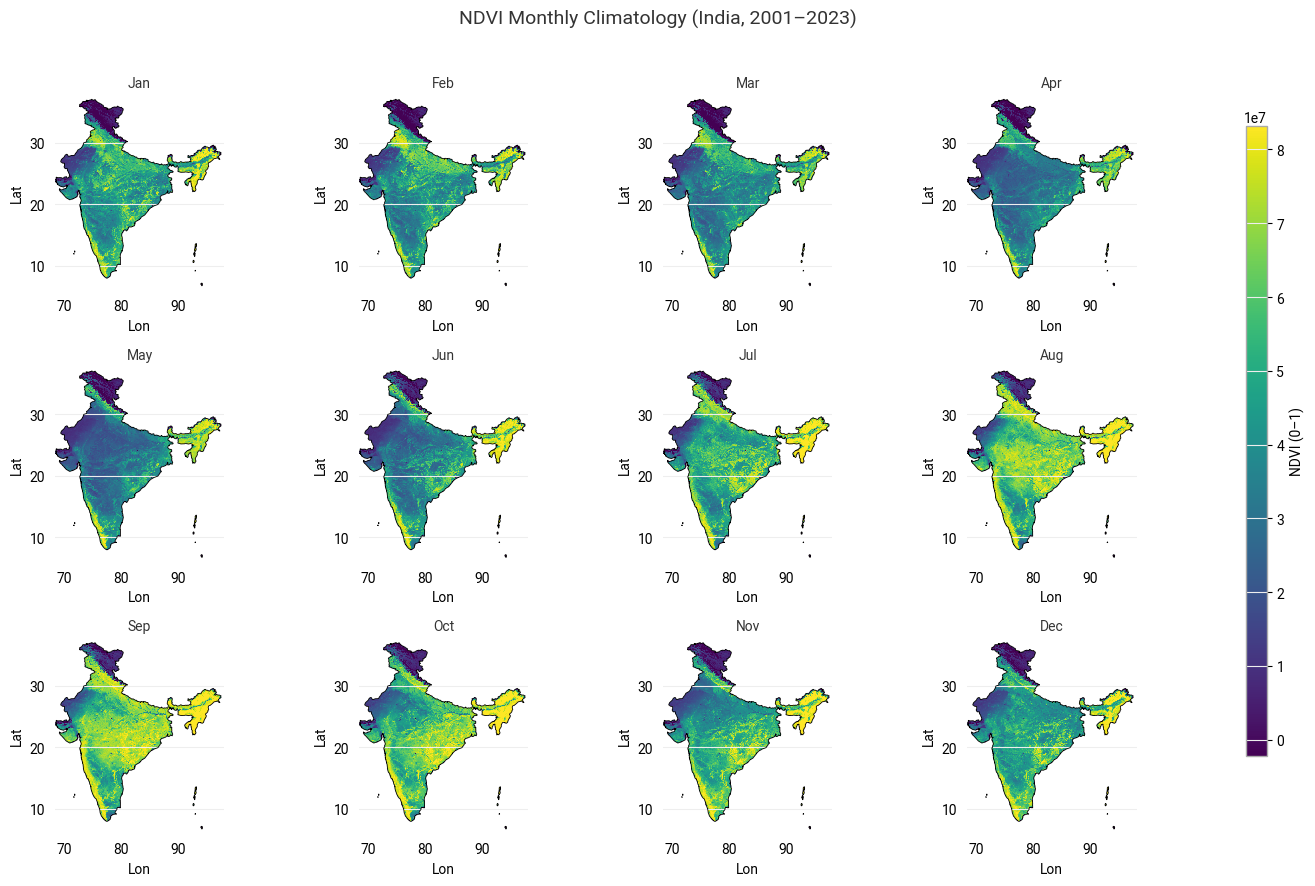

In [15]:
# NDVI monthly climatology (single 12-panel figure)
# Input: scaled-only NDVI NetCDF you just created

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd

# ---------- user paths ----------
NC_PATH = r"C:\Drought\Regridding and data clipping\MODIS_NDVI\MODIS_NDVI_India_0p05deg_SCALEDONLY_2001-2023.nc"
SHP_PATH = r"C:\Drought\India Shapefile\indiashapefile\India_with_jk.shp"  # optional outline
USE_SHAPE_OUTLINE = True
USE_FIXED_RANGE = False   # True => force NDVI color scale to 0..1
# -------------------------------

# Load NDVI
ds = xr.open_dataset(NC_PATH)
# Choose variable with (time, lat, lon)
cands = [v for v in ds.data_vars if set(['time','lat','lon']).issubset(ds[v].dims)]
varname = 'NDVI' if 'NDVI' in ds else (cands[0] if cands else None)
if varname is None:
    raise ValueError("No variable with dims (time, lat, lon) found.")
da = ds[varname]

# Ensure latitude increases (south->north)
if da['lat'][0] > da['lat'][-1]:
    da = da.sortby('lat')

# Monthly climatology (mean for each calendar month across years)
clim = da.groupby('time.month').mean('time', keep_attrs=True)  # dims: month, lat, lon

# Shared color scale
if USE_FIXED_RANGE:
    vmin, vmax = 0.0, 1.0
else:
    vals = clim.values
    vmin = float(np.nanpercentile(vals, 2))
    vmax = float(np.nanpercentile(vals, 98))
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        vmin, vmax = float(np.nanmin(vals)), float(np.nanmax(vals))

# Optional India outline
outline = None
if USE_SHAPE_OUTLINE:
    gdf = gpd.read_file(SHP_PATH).to_crs(epsg=4326)
    if len(gdf) > 1:
        gdf = gdf.dissolve()
    outline = gdf.explode(index_parts=False).boundary

# Plot: single figure with 12 subplots
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
fig, axes = plt.subplots(3, 4, figsize=(14, 9))
axes = axes.ravel()

LON = clim['lon'].values
LAT = clim['lat'].values
XX, YY = np.meshgrid(LON, LAT)

mappable = None
for i in range(12):
    ax = axes[i]
    field = clim.sel(month=i+1).values
    mappable = ax.pcolormesh(XX, YY, field, shading="auto", vmin=vmin, vmax=vmax)
    ax.set_title(month_labels[i], fontsize=10)
    ax.set_xlabel("Lon"); ax.set_ylabel("Lat")
    if outline is not None:
        outline.plot(ax=ax, linewidth=0.6, color="k")

# Shared colorbar
cax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cb = fig.colorbar(mappable, cax=cax)
cb.set_label(f"{varname} (0–1)")

# Figure title with year span from data
y0 = int(da['time'].dt.year.min().item())
y1 = int(da['time'].dt.year.max().item())
fig.suptitle(f"{varname} Monthly Climatology (India, {y0}–{y1})", y=0.98, fontsize=14)

plt.tight_layout(rect=[0, 0, 0.9, 0.96])
plt.show()


In [17]:
# Fix NDVI scale in-place by writing a corrected copy
import xarray as xr
from pathlib import Path
import numpy as np

IN_NC  = r"C:\Drought\Regridding and data clipping\MODIS_NDVI\MODIS_NDVI_India_0p05deg_SCALEDONLY_2001-2023.nc"
p = Path(IN_NC)
OUT_NC = str(p.with_name(p.stem.replace("SCALEDONLY", "SCALEFIX") + p.suffix))

ds = xr.open_dataset(IN_NC)
# pick the (time,lat,lon) variable
var = "NDVI" if "NDVI" in ds.data_vars else next(v for v in ds.data_vars if set(["time","lat","lon"]).issubset(ds[v].dims))

# Current values ≈ raw * 10000; we want raw * 0.0001 → multiply by (0.0001 / 10000) = 1e-8
ds[var] = (ds[var] * 1e-8).astype("float32")

# (Optional) keep NDVI within a sensible physical range
# ds[var] = ds[var].where((ds[var] >= -0.2) & (ds[var] <= 1.0))

# Update metadata
ds[var].attrs.update({
    "long_name": "MOD13C2 NDVI (corrected scale)",
    "units": "1",
    "scale_applied": 0.0001,
    "note": "Corrected from mistaken ×10000; applied ×1e-8 to this file."
})

enc = {var: {"zlib": True, "complevel": 4, "dtype": "float32"}}
ds.to_netcdf(OUT_NC, format="NETCDF4", encoding=enc)
print("Wrote:", OUT_NC)


Wrote: C:\Drought\Regridding and data clipping\MODIS_NDVI\MODIS_NDVI_India_0p05deg_SCALEFIX_2001-2023.nc


In [27]:
#vodc data processing
"""
VODCA C-band (daily) → monthly means → clip India → regrid 0.05° → ONE NetCDF

Inputs:
  Root:   C:\Drought\VODC\VODCA_C-band_2002-2018_v01.0.0\C-Band
  Years:  2003..2018 (each year in its own folder)
  Files:  vodca_v01-0_C-band_YYYY-MM-DD.nc (daily)

Output:
  C:\Drought\Regridding and data clipping\VODC\VODCA_Cband_monthly_India_0p05deg_2003-2018.nc
"""

import os
from pathlib import Path
import warnings
import numpy as np
import xarray as xr
import geopandas as gpd
import rioxarray
import rasterio

warnings.filterwarnings("ignore", category=FutureWarning)

# --------- USER PATHS ---------
IN_ROOT = r"C:\Drought\VODC\VODCA_C-band_2002-2018_v01.0.0\C-Band"
INDIA_SHP_DIR = r"C:\Drought\India Shapefile\indiashapefile"
OUT_DIR  = r"C:\Drought\Regridding and data clipping\VODC"
OUT_NAME = "VODCA_Cband_monthly_India_0p05deg_2003-2018.nc"
# ------------------------------

YEAR_FIRST = 2003
YEAR_LAST  = 2018
CRS_EPSG = 4326
TARGET_RES_DEG = 0.05

# performance / compression
CHUNKS = {"time": 240, "lat": 800, "lon": 800}
ENC = dict(zlib=True, complevel=4)

# ---------- helpers ----------
def ensure_spatial(obj):
    """Ensure object has lon/lat increasing and geo metadata for rioxarray."""
    if "x" in obj.dims or "y" in obj.dims:
        rename = {}
        if "x" in obj.dims: rename["x"] = "lon"
        if "y" in obj.dims: rename["y"] = "lat"
        obj = obj.rename(rename)
    if "lat" in obj.coords and obj["lat"][0] > obj["lat"][-1]:
        obj = obj.sortby("lat")
    if "lon" in obj.coords and obj["lon"][0] > obj["lon"][-1]:
        obj = obj.sortby("lon")
    obj = obj.rio.write_crs(CRS_EPSG, inplace=False).rio.set_spatial_dims("lon", "lat", inplace=False)
    return obj

def build_template_from_shape(gdf, res_deg=TARGET_RES_DEG, pad=0.25):
    """Template grid covering India bbox at target resolution."""
    minx, miny, maxx, maxy = gdf.to_crs(epsg=CRS_EPSG).total_bounds
    minx -= pad; miny -= pad; maxx += pad; maxy += pad
    lons = np.arange(minx, maxx + 1e-12, res_deg)
    lats = np.arange(miny, maxy + 1e-12, res_deg)
    t = xr.Dataset(coords={"lon": ("lon", lons), "lat": ("lat", lats)})
    t = t.rio.write_crs(CRS_EPSG, inplace=False).rio.set_spatial_dims("lon","lat", inplace=False)
    return t

def quick_bbox_slice(da, template):
    minx, miny, maxx, maxy = template.rio.bounds()
    return da.sel(lon=slice(minx, maxx), lat=slice(miny, maxy))

def clip_to_india(da, india_gdf):
    da = ensure_spatial(da)
    gdf = india_gdf.to_crs(epsg=CRS_EPSG)
    return da.rio.clip(gdf.geometry, gdf.crs, drop=True, invert=False)

def regrid_to_template(da, template):
    da = ensure_spatial(da)
    t  = template
    if len(t.data_vars) == 0:
        t = t.assign(_dummy=(("lat","lon"), np.zeros((t.sizes["lat"], t.sizes["lon"]))))
        t = t.rio.write_crs(CRS_EPSG, inplace=False).rio.set_spatial_dims("lon","lat", inplace=False)
    out = da.rio.reproject_match(t, resampling=rasterio.enums.Resampling.bilinear)
    # sometimes rioxarray returns x/y dims after reprojection; normalize:
    if "x" in out.dims or "y" in out.dims:
        out = out.rename({k: v for k, v in {"x": "lon", "y": "lat"}.items() if k in out.dims})
    return out

def open_year_ds(year_path: Path) -> xr.Dataset:
    """Open all daily files for a given year into a Dataset (vod only)."""
    files = sorted(year_path.glob("vodca_v01-0_C-band_*.nc"))
    if not files:
        raise FileNotFoundError(f"No daily files in {year_path}")
    # safer open: use engine try-order; chunk on time
    engines = (None, "netcdf4", "h5netcdf", "scipy")
    last_err = None
    for eng in engines:
        try:
            ds = xr.open_mfdataset(
                [str(p) for p in files],
                combine="by_coords",
                parallel=False,
                chunks={"time": 90, "lat": 360, "lon": 360},
                engine=eng
            )
            # keep only VOD to save memory
            if "vod" in ds:
                ds = ds[["vod"]]
            else:
                # some files may store it under different casing; harmonize
                candidates = [v for v in ds.data_vars if v.lower() == "vod"]
                if candidates:
                    ds = ds[[candidates[0]]].rename({candidates[0]: "vod"})
                else:
                    raise KeyError("Variable 'vod' not found.")
            return ds
        except Exception as e:
            last_err = e
    raise RuntimeError(f"Failed to open {year_path} with available engines. Last error: {last_err}")

# ---------- main ----------
def main():
    # India shape + target template
    shp_list = list(Path(INDIA_SHP_DIR).glob("*.shp"))
    if not shp_list:
        raise FileNotFoundError(f"No .shp in {INDIA_SHP_DIR}")
    india = gpd.read_file(shp_list[0])
    template = build_template_from_shape(india, res_deg=TARGET_RES_DEG)

    out_monthlies = []

    for year in range(YEAR_FIRST, YEAR_LAST + 1):
        ydir = Path(IN_ROOT) / f"{year}"
        if not ydir.exists():
            print(f"[{year}] SKIP (folder not found): {ydir}")
            continue

        print(f"[{year}] opening daily files…")
        ds_daily = open_year_ds(ydir)

        # ensure lon/lat meta
        ds_daily = ensure_spatial(ds_daily)

        # monthly mean (time to first-of-month)
        ds_mon = ds_daily.resample(time="MS").mean(keep_attrs=True, skipna=True)

        # speed: crop to bbox first, then precise clip, then 0.05° regrid
        da = ds_mon["vod"]
        da = quick_bbox_slice(da, template)
        da = clip_to_india(da, india)
        da = regrid_to_template(da, template)

        # tidy attrs
        da.name = "vod"
        da.attrs.update({
            "long_name": "Vegetation Optical Depth (C-band), monthly mean",
            "units": ds_daily["vod"].attrs.get("units", ""),  # keep units if present
            "processing_lineage": "daily→monthly mean; clipped to India; regridded to 0.05° (bilinear)",
            "source": "VODCA C-band v01.0.0",
        })
        out_monthlies.append(da)

        # close to release file handles
        ds_daily.close()

    if not out_monthlies:
        raise RuntimeError("No monthly data produced. Check input folders/files.")

    print("Concatenating months across all years…")
    vod_mon_all = xr.concat(out_monthlies, dim="time").sortby("time")

    # wrap to dataset and write
    ds_out = vod_mon_all.to_dataset()
    try:
        ds_out = ds_out.chunk(CHUNKS)
    except Exception:
        pass
    enc = {v: {**ENC} for v in ds_out.data_vars}

    ds_out.attrs.update({
        "title": "VODCA C-band monthly mean – India 0.05°",
        "Conventions": "CF-1.8",
        "crs": f"EPSG:{CRS_EPSG}",
        "history": "Aggregated from daily VOD; clipped to India; regridded to 0.05° bilinear",
        "temporal_coverage": f"{YEAR_FIRST}-01 to {YEAR_LAST}-12",
        "spatial_resolution": "0.05 degree",
    })

    os.makedirs(OUT_DIR, exist_ok=True)
    out_path = str(Path(OUT_DIR) / OUT_NAME)
    print(f"Writing NetCDF → {out_path}")
    # try several engines for portability
    try:
        ds_out.to_netcdf(out_path, engine="netcdf4", encoding=enc)
    except Exception:
        try:
            ds_out.to_netcdf(out_path, engine="h5netcdf", encoding=enc)
        except Exception:
            ds_out.to_netcdf(out_path, engine="scipy", encoding=enc)
    print("Done.")

if __name__ == "__main__":
    main()


<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Vikas.Patel\AppData\Local\Temp\ipykernel_18324\3214466341.py:2: SyntaxWarning: invalid escape sequence '\D'
  """


[2003] opening daily files…
[2004] opening daily files…
[2005] opening daily files…
[2006] opening daily files…
[2007] opening daily files…
[2008] opening daily files…
[2009] opening daily files…
[2010] opening daily files…
[2011] opening daily files…
[2012] opening daily files…
[2013] opening daily files…
[2014] opening daily files…
[2015] opening daily files…
[2016] opening daily files…
[2017] opening daily files…
[2018] opening daily files…
Concatenating months across all years…
Writing NetCDF → C:\Drought\Regridding and data clipping\VODC\VODCA_Cband_monthly_India_0p05deg_2003-2018.nc
Done.


In [37]:
# vodc ku band data processing. 
import os
from pathlib import Path
import warnings
import numpy as np
import xarray as xr
import geopandas as gpd
import rioxarray
import rasterio

warnings.filterwarnings("ignore", category=FutureWarning)

# ---------- USER PATHS ----------
IN_ROOT = r"C:\Drought\VODC\VODCA_Ku-band_1987-2017_v01.0.0\Ku-band"
INDIA_SHP_DIR = r"C:\Drought\India Shapefile\indiashapefile"
OUT_DIR  = r"C:\Drought\Regridding and data clipping\VODCKu"
OUT_NAME = "VODCA_Kuband_monthly_India_0p05deg_2000-2016.nc"
# --------------------------------

YEAR_FIRST = 2000
YEAR_LAST  = 2016
CRS_EPSG = 4326
TARGET_RES_DEG = 0.05

# performance / compression
CHUNKS = {"time": 240, "lat": 800, "lon": 800}
ENC = dict(zlib=True, complevel=4)

# ---------- helpers ----------
def ensure_spatial(obj):
    if "x" in obj.dims or "y" in obj.dims:
        ren = {}
        if "x" in obj.dims: ren["x"] = "lon"
        if "y" in obj.dims: ren["y"] = "lat"
        obj = obj.rename(ren)
    if "lat" in obj.coords and obj["lat"][0] > obj["lat"][-1]:
        obj = obj.sortby("lat")
    if "lon" in obj.coords and obj["lon"][0] > obj["lon"][-1]:
        obj = obj.sortby("lon")
    obj = obj.rio.write_crs(CRS_EPSG, inplace=False).rio.set_spatial_dims("lon", "lat", inplace=False)
    return obj

def build_template_from_shape(gdf, res_deg=TARGET_RES_DEG, pad=0.25):
    minx, miny, maxx, maxy = gdf.to_crs(epsg=CRS_EPSG).total_bounds
    minx -= pad; miny -= pad; maxx += pad; maxy += pad
    lons = np.arange(minx, maxx + 1e-12, res_deg)
    lats = np.arange(miny, maxy + 1e-12, res_deg)
    t = xr.Dataset(coords={"lon": ("lon", lons), "lat": ("lat", lats)})
    t = t.rio.write_crs(CRS_EPSG, inplace=False).rio.set_spatial_dims("lon","lat", inplace=False)
    return t

def quick_bbox_slice(da, template):
    minx, miny, maxx, maxy = template.rio.bounds()
    return da.sel(lon=slice(minx, maxx), lat=slice(miny, maxy))

def clip_to_india(da, india_gdf):
    da = ensure_spatial(da)
    gdf = india_gdf.to_crs(epsg=CRS_EPSG)
    return da.rio.clip(gdf.geometry, gdf.crs, drop=True, invert=False)

def regrid_to_template(da, template):
    da = ensure_spatial(da)
    t  = template
    if len(t.data_vars) == 0:
        t = t.assign(_dummy=(("lat","lon"), np.zeros((t.sizes["lat"], t.sizes["lon"]))))
        t = t.rio.write_crs(CRS_EPSG, inplace=False).rio.set_spatial_dims("lon","lat", inplace=False)
    out = da.rio.reproject_match(t, resampling=rasterio.enums.Resampling.bilinear)
    if "x" in out.dims or "y" in out.dims:
        out = out.rename({k: v for k, v in {"x": "lon", "y": "lat"}.items() if k in out.dims})
    return out

def list_daily_files(year_path: Path):
    """Return sorted daily files for the year, matching both Ku-band and K-band names."""
    patterns = [
        "vodca_v01-0_Ku-band_*.nc",
        "vodca_v01-0_K-band_*.nc",
        "*Ku-band_*.nc",
        "*K-band_*.nc",
    ]
    files = []
    for pat in patterns:
        files.extend(year_path.glob(pat))
    files = sorted(set(files))
    return files

def open_year_ds(year_path: Path) -> xr.Dataset:
    files = list_daily_files(year_path)
    if not files:
        raise FileNotFoundError(f"No daily files in {year_path}")
    engines = (None, "netcdf4", "h5netcdf", "scipy")
    last_err = None
    for eng in engines:
        try:
            ds = xr.open_mfdataset(
                [str(p) for p in files],
                combine="by_coords",
                parallel=False,
                chunks={"time": 90, "lat": 360, "lon": 360},
                engine=eng
            )
            # keep VOD only
            if "vod" in ds:
                ds = ds[["vod"]]
            else:
                cand = [v for v in ds.data_vars if v.lower() == "vod"]
                if cand:
                    ds = ds[[cand[0]]].rename({cand[0]: "vod"})
                else:
                    raise KeyError("Variable 'vod' not found.")
            return ds
        except Exception as e:
            last_err = e
    raise RuntimeError(f"Failed to open {year_path} with available engines. Last error: {last_err}")

# ---------- main ----------
def main():
    # India shape + template
    shp_list = list(Path(INDIA_SHP_DIR).glob("*.shp"))
    if not shp_list:
        raise FileNotFoundError(f"No .shp in {INDIA_SHP_DIR}")
    india = gpd.read_file(shp_list[0])
    template = build_template_from_shape(india, res_deg=TARGET_RES_DEG)

    out_monthlies = []

    for year in range(YEAR_FIRST, YEAR_LAST + 1):
        ydir = Path(IN_ROOT) / f"{year}"
        if not ydir.exists():
            print(f"[{year}] SKIP (folder not found): {ydir}")
            continue

        files = list_daily_files(ydir)
        if not files:
            print(f"[{year}] WARNING: no daily files matched in {ydir}")
            continue
        print(f"[{year}] opening daily files… ({len(files)} files)")

        ds_daily = open_year_ds(ydir)
        ds_daily = ensure_spatial(ds_daily)

        # monthly mean at month start (MS)
        ds_mon = ds_daily.resample(time="MS").mean(keep_attrs=True, skipna=True)

        da = ds_mon["vod"]
        da = quick_bbox_slice(da, template)
        da = clip_to_india(da, india)
        da = regrid_to_template(da, template)

        da.name = "vod"
        da.attrs.update({
            "long_name": "Vegetation Optical Depth (Ku/K band), monthly mean",
            "units": ds_daily["vod"].attrs.get("units", ""),
            "processing_lineage": "daily→monthly mean; clipped to India; regridded to 0.05° (bilinear)",
            "source": "VODCA Ku-band v01.0.0",
        })
        out_monthlies.append(da)
        ds_daily.close()

    if not out_monthlies:
        raise RuntimeError("No monthly data produced. Check input folders/files/patterns.")

    print("Concatenating months across all years…")
    vod_mon_all = xr.concat(out_monthlies, dim="time").sortby("time")

    ds_out = vod_mon_all.to_dataset()
    try:
        ds_out = ds_out.chunk(CHUNKS)
    except Exception:
        pass
    enc = {v: {**ENC} for v in ds_out.data_vars}

    ds_out.attrs.update({
        "title": "VODCA Ku/K-band monthly mean – India 0.05°",
        "Conventions": "CF-1.8",
        "crs": f"EPSG:{CRS_EPSG}",
        "history": "Aggregated from daily VOD; clipped to India; regridded to 0.05° bilinear",
        "temporal_coverage": f"{YEAR_FIRST}-01 to {YEAR_LAST}-12",
        "spatial_resolution": "0.05 degree",
    })

    os.makedirs(OUT_DIR, exist_ok=True)
    out_path = str(Path(OUT_DIR) / OUT_NAME)
    print(f"Writing NetCDF → {out_path}")
    try:
        ds_out.to_netcdf(out_path, engine="netcdf4", encoding=enc)
    except Exception:
        try:
            ds_out.to_netcdf(out_path, engine="h5netcdf", encoding=enc)
        except Exception:
            ds_out.to_netcdf(out_path, engine="scipy", encoding=enc)
    print("Done.")

if __name__ == "__main__":
    main()


[2000] opening daily files… (366 files)
[2001] opening daily files… (365 files)
[2002] opening daily files… (365 files)
[2003] opening daily files… (365 files)
[2004] opening daily files… (366 files)
[2005] opening daily files… (365 files)
[2006] opening daily files… (365 files)
[2007] opening daily files… (365 files)
[2008] opening daily files… (366 files)
[2009] opening daily files… (365 files)
[2010] opening daily files… (365 files)
[2011] opening daily files… (365 files)
[2012] opening daily files… (366 files)
[2013] opening daily files… (365 files)
[2014] opening daily files… (365 files)
[2015] opening daily files… (365 files)
[2016] opening daily files… (366 files)
Concatenating months across all years…
Writing NetCDF → C:\Drought\Regridding and data clipping\VODCKu\VODCA_Kuband_monthly_India_0p05deg_2000-2016.nc
Done.


In [39]:
import os
from pathlib import Path
import warnings
import numpy as np
import xarray as xr
import geopandas as gpd
import rioxarray
import rasterio

warnings.filterwarnings("ignore", category=FutureWarning)

# ---------- USER PATHS ----------
IN_ROOT = r"C:\Drought\VODC\VODCA_X-band_1997-2018_v01.0.0\X-band"
INDIA_SHP_DIR = r"C:\Drought\India Shapefile\indiashapefile"
OUT_DIR  = r"C:\Drought\Regridding and data clipping\VODX"
OUT_NAME = "VODCA_Xband_monthly_India_0p05deg_2000-2018.nc"
# --------------------------------

YEAR_FIRST = 2000
YEAR_LAST  = 2018
CRS_EPSG = 4326
TARGET_RES_DEG = 0.05

# performance / compression
CHUNKS = {"time": 240, "lat": 800, "lon": 800}
ENC = dict(zlib=True, complevel=4)

# ---------- helpers ----------
def ensure_spatial(obj):
    if "x" in obj.dims or "y" in obj.dims:
        ren = {}
        if "x" in obj.dims: ren["x"] = "lon"
        if "y" in obj.dims: ren["y"] = "lat"
        obj = obj.rename(ren)
    if "lat" in obj.coords and obj["lat"][0] > obj["lat"][-1]:
        obj = obj.sortby("lat")
    if "lon" in obj.coords and obj["lon"][0] > obj["lon"][-1]:
        obj = obj.sortby("lon")
    obj = obj.rio.write_crs(CRS_EPSG, inplace=False).rio.set_spatial_dims("lon", "lat", inplace=False)
    return obj

def build_template_from_shape(gdf, res_deg=TARGET_RES_DEG, pad=0.25):
    minx, miny, maxx, maxy = gdf.to_crs(epsg=CRS_EPSG).total_bounds
    minx -= pad; miny -= pad; maxx += pad; maxy += pad
    lons = np.arange(minx, maxx + 1e-12, res_deg)
    lats = np.arange(miny, maxy + 1e-12, res_deg)
    t = xr.Dataset(coords={"lon": ("lon", lons), "lat": ("lat", lats)})
    t = t.rio.write_crs(CRS_EPSG, inplace=False).rio.set_spatial_dims("lon","lat", inplace=False)
    return t

def quick_bbox_slice(da, template):
    minx, miny, maxx, maxy = template.rio.bounds()
    return da.sel(lon=slice(minx, maxx), lat=slice(miny, maxy))

def clip_to_india(da, india_gdf):
    da = ensure_spatial(da)
    gdf = india_gdf.to_crs(epsg=CRS_EPSG)
    return da.rio.clip(gdf.geometry, gdf.crs, drop=True, invert=False)

def regrid_to_template(da, template):
    da = ensure_spatial(da)
    t  = template
    if len(t.data_vars) == 0:
        t = t.assign(_dummy=(("lat","lon"), np.zeros((t.sizes["lat"], t.sizes["lon"]))))
        t = t.rio.write_crs(CRS_EPSG, inplace=False).rio.set_spatial_dims("lon","lat", inplace=False)
    out = da.rio.reproject_match(t, resampling=rasterio.enums.Resampling.bilinear)
    if "x" in out.dims or "y" in out.dims:
        out = out.rename({k: v for k, v in {"x": "lon", "y": "lat"}.items() if k in out.dims})
    return out

def list_daily_files(year_path: Path):
    """Return sorted daily files for the year (X-band pattern)."""
    patterns = [
        "vodca_v01-0_X-band_*.nc",
        "*X-band_*.nc",
    ]
    files = []
    for pat in patterns:
        files.extend(year_path.glob(pat))
    return sorted(set(files))

def open_year_ds(year_path: Path) -> xr.Dataset:
    files = list_daily_files(year_path)
    if not files:
        raise FileNotFoundError(f"No daily files in {year_path}")
    engines = (None, "netcdf4", "h5netcdf", "scipy")
    last_err = None
    for eng in engines:
        try:
            ds = xr.open_mfdataset(
                [str(p) for p in files],
                combine="by_coords",
                parallel=False,
                chunks={"time": 90, "lat": 360, "lon": 360},
                engine=eng
            )
            # keep VOD only
            if "vod" in ds:
                ds = ds[["vod"]]
            else:
                cand = [v for v in ds.data_vars if v.lower() == "vod"]
                if cand:
                    ds = ds[[cand[0]]].rename({cand[0]: "vod"})
                else:
                    raise KeyError("Variable 'vod' not found.")
            return ds
        except Exception as e:
            last_err = e
    raise RuntimeError(f"Failed to open {year_path} with available engines. Last error: {last_err}")

# ---------- main ----------
def main():
    # India shape + template
    shp_list = list(Path(INDIA_SHP_DIR).glob("*.shp"))
    if not shp_list:
        raise FileNotFoundError(f"No .shp in {INDIA_SHP_DIR}")
    india = gpd.read_file(shp_list[0])
    template = build_template_from_shape(india, res_deg=TARGET_RES_DEG)

    out_monthlies = []

    for year in range(YEAR_FIRST, YEAR_LAST + 1):
        ydir = Path(IN_ROOT) / f"{year}"
        if not ydir.exists():
            print(f"[{year}] SKIP (folder not found): {ydir}")
            continue

        files = list_daily_files(ydir)
        if not files:
            print(f"[{year}] WARNING: no daily files matched in {ydir}")
            continue
        print(f"[{year}] opening daily files… ({len(files)} files)")

        ds_daily = open_year_ds(ydir)
        ds_daily = ensure_spatial(ds_daily)

        # monthly mean at month start (MS)
        ds_mon = ds_daily.resample(time="MS").mean(keep_attrs=True, skipna=True)

        da = ds_mon["vod"]
        da = quick_bbox_slice(da, template)
        da = clip_to_india(da, india)
        da = regrid_to_template(da, template)

        da.name = "vod"
        da.attrs.update({
            "long_name": "Vegetation Optical Depth (X-band), monthly mean",
            "units": ds_daily["vod"].attrs.get("units", ""),
            "processing_lineage": "daily→monthly mean; clipped to India; regridded to 0.05° (bilinear)",
            "source": "VODCA X-band v01.0.0",
        })
        out_monthlies.append(da)
        ds_daily.close()

    if not out_monthlies:
        raise RuntimeError("No monthly data produced. Check input folders/files/patterns.")

    print("Concatenating months across all years…")
    vod_mon_all = xr.concat(out_monthlies, dim="time").sortby("time")

    ds_out = vod_mon_all.to_dataset()
    try:
        ds_out = ds_out.chunk(CHUNKS)
    except Exception:
        pass
    enc = {v: {**ENC} for v in ds_out.data_vars}

    ds_out.attrs.update({
        "title": "VODCA X-band monthly mean – India 0.05°",
        "Conventions": "CF-1.8",
        "crs": f"EPSG:{CRS_EPSG}",
        "history": "Aggregated from daily VOD; clipped to India; regridded to 0.05° bilinear",
        "temporal_coverage": f"{YEAR_FIRST}-01 to {YEAR_LAST}-12",
        "spatial_resolution": "0.05 degree",
    })

    os.makedirs(OUT_DIR, exist_ok=True)
    out_path = str(Path(OUT_DIR) / OUT_NAME)
    print(f"Writing NetCDF → {out_path}")
    try:
        ds_out.to_netcdf(out_path, engine="netcdf4", encoding=enc)
    except Exception:
        try:
            ds_out.to_netcdf(out_path, engine="h5netcdf", encoding=enc)
        except Exception:
            ds_out.to_netcdf(out_path, engine="scipy", encoding=enc)
    print("Done.")

if __name__ == "__main__":
    main()


<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Vikas.Patel\AppData\Local\Temp\ipykernel_18324\1224358426.py:2: SyntaxWarning: invalid escape sequence '\D'
  """


[2000] opening daily files… (366 files)
[2001] opening daily files… (365 files)
[2002] opening daily files… (365 files)
[2003] opening daily files… (365 files)
[2004] opening daily files… (366 files)
[2005] opening daily files… (365 files)
[2006] opening daily files… (365 files)
[2007] opening daily files… (365 files)
[2008] opening daily files… (366 files)
[2009] opening daily files… (365 files)
[2010] opening daily files… (365 files)
[2011] opening daily files… (365 files)
[2012] opening daily files… (366 files)
[2013] opening daily files… (365 files)
[2014] opening daily files… (365 files)
[2015] opening daily files… (365 files)
[2016] opening daily files… (366 files)
[2017] opening daily files… (365 files)
[2018] opening daily files… (365 files)
Concatenating months across all years…
Writing NetCDF → C:\Drought\Regridding and data clipping\VODX\VODCA_Xband_monthly_India_0p05deg_2000-2018.nc
Done.
